In [1]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm

import pickle

import matplotlib.pyplot as plt
import plotly.graph_objects as go

import matplotlib.ticker as ticker
import matplotlib.ticker as mtick
import matplotlib.colors as mcolors
import colorsys

from google.cloud import bigquery

import plotly.io as pio
pio.renderers.default = 'iframe'

from scipy.stats import fisher_exact
from scipy.stats import chi2_contingency
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

In [302]:
cset_colors = ["#0B1F41","#003DA6","#B53A6D","#7AC4A5","#F17F4C","#15AFD0","#839DC5","#E5BF21"]
cset_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

In [207]:
mos_color_dict = {"biology":'#da1645ff',
                 #"business":"#44ad40ff",
                 "chemistry":"#4fcdf2ff",
                 "computer science":"#3f53d2ff",
                 "earth science":"#ec782fff",
                 "engineering":"#8209abff",
                 "humanities":"#fcdf1bff",
                 "materials science":"#e51ce3ff",
                 "mathematics":"#bbef3bff",
                 "medicine":"#468f85ff",
                 "physics":"#f5b5cfff",
                 "social science":"#d5b4ffff"}

In [4]:
client = bigquery.Client()

In [6]:
with open('../data/all_cluster_predictions.pckl','rb') as fil:
    all_cluster_predictions = pickle.load(fil)
with open('../data/all_cluster_data.pckl','rb') as fil:
    all_cluster_data = pickle.load(fil)
all_cluster_data_predictions = pd.merge(all_cluster_data, all_cluster_predictions, on = ['cluster_id', 'forecast_year'], how='inner')

# Loading in testing and training data
with open('../data/training_data.pckl','rb') as fil:
    training_data = pickle.load(fil)
with open('../data/testing_data.pckl','rb') as fil:
    testing_data = pickle.load(fil)

# Training and testing data stats

In [7]:
print(f'There are {training_data['cluster_id'].nunique():,.0f} clusters in the training set')
print(f'{100*training_data['cluster_id'].nunique()/all_cluster_data['cluster_id'].nunique():.0f}% of clusters')
print(f'There are {sum(training_data['forecast_year'] <= 2022):,.0f} data points in the training set.')

There are 73,276 clusters in the training set
80% of clusters
There are 586,208 data points in the training set.


In [8]:
print(f'There are {testing_data['cluster_id'].nunique():,.0f} clusters in the testing set')
print(f'{100*testing_data['cluster_id'].nunique()/all_cluster_data['cluster_id'].nunique():.0f}% of clusters')
print(f'There are {sum(testing_data['forecast_year'] <= 2022):,.0f} data points in the testing set.')

There are 18,318 clusters in the testing set
20% of clusters
There are 146,544 data points in the testing set.


In [9]:
n_data_EG = sum((all_cluster_data_predictions['forecast_year'] <= 2022) & (all_cluster_data_predictions['EG_3Yr'] == 1))
n_data = sum(all_cluster_data_predictions['forecast_year'] <= 2022)
print(f'{100*n_data_EG/n_data:.1f}% of data have extreme growth')
print(f'There are {n_data:,.0f} of data points')

7.7% of data have extreme growth
There are 732,752 of data points


# NN Model Loading

In [10]:
def zscore(column):
    zcolumn = (column - column.mean())/column.std()
    return zcolumn
def zcut(column):
    zcolumn = zscore(column)
    return zcolumn.clip(upper=4,lower=-4)

In [11]:
feature_list = [
    'L0',
    'L1',
    'L2',
    'L3',
    'L4',
    'L5',
    'L6',
    'L7',
    'L8',
    'L9',
    'L10',
    'L11',
    'L12',
    'L13',
    'L14',
    'L15',
    'I0',
    'I1',
    'D0',
    'D1',
    'D2',
    'D3',
    'F0',
    'F1',
    'F2',
    'F3',
    'F4',
    'F5',
    'F6',
    'F7',
    'F8',
    'F9',
    'F10',
    'F11',
    'N0',
    'N1',
    'N2',
    'N3',
    'N4',
    'N5',
    'N6',
    'P0',
    'C0',
    'C1',
    'C2',
    'CC0',
    'CC1',
    'CC2',
    'S0',
    'S1',
    'S2',
    'S3',
    'S4',
    'S5',
    'S6',
    'S7',
    'S8',
    'S9',
    'S10',
    'S11',
    'S12',
    'S13',
    'S14',
    'S15',
    'dS0',
    'dS1',
    'dS2',
    'dS3',
    'dS4',
    'dS5',
    'dS6',
    'dS7',
    'dS8',
    'dS9',
    'dS10',
    'dS11',
    'dS12',
    'dS13',
    'dS14',
    'CS0',
    'CS1',
    'CS2',
    'CS3',
    'CS4',
    'CS5',
    'CS6',
    'CS7',
    'CS8',
    'CS9',
    'CS10',
    'CS11',
    'CS12',
    'CS13',
    'CS14',
    'CS15',
    'dCS0',
    'dCS1',
    'dCS2',
    'dCS3',
    'dCS4',
    'dCS5',
    'dCS6',
    'dCS7',
    'dCS8',
    'dCS9',
    'dCS10',
    'dCS11',
    'dCS12',
    'dCS13',
    'dCS14',
    'RS0',
    'RS1',
    'RS2',
    'RS3',
    'RS4',
    'RS5',
    'RS6',
    'RS7',
    'RS8',
    'RS9',
    'RS10',
    'RS11',
    'RS12',
    'RS13',
    'RS14',
    'RS15',
    'dRS0',
    'dRS1',
    'dRS2',
    'dRS3',
    'dRS4',
    'dRS5',
    'dRS6',
    'dRS7',
    'dRS8',
    'dRS9',
    'dRS10',
    'dRS11',
    'dRS12',
    'dRS13',
    'dRS14',
]
transforms = {k: zcut for k in feature_list}

In [12]:
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(SimpleNN, self).__init__()
        # Define fully connected layers (nn.Linear)
        self.fc1 = nn.Linear(input_size, hidden_size) 
        self.fc2 = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        # Apply ReLU activation after the first layer
        out = self.fc1(x)
        out = F.relu(out)
        # No activation function needed for the output layer here, 
        # as the loss function (e.g., CrossEntropyLoss) will handle Softmax internally
        out = self.fc2(out) 
        return out

In [347]:
n_classes = 2
n_features = len(transforms)
input_size = n_features 
hidden_size = 128*2
num_classes = n_classes

# create the model
model = SimpleNN(input_size, hidden_size, num_classes)

In [348]:
weights_path = "../ML_models/finalModel_local/simpleNN_141features_256hiddensize_EG_3Yr_epoch200.pt"
state_dict = torch.load(weights_path, map_location=torch.device('cpu'))
model.load_state_dict(state_dict)
model.eval()

SimpleNN(
  (fc1): Linear(in_features=141, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=2, bias=True)
)

In [17]:
growth_features_2025 = pd.read_json('../data/cluster_features_2025.jsonl', lines=True).sort_values('cluster_id')

In [18]:
x_2025 = pd.concat([transforms[k](growth_features_2025[k]) for k in transforms.keys()], axis=1).values

In [19]:
def find_model_predictions(x):
    y_pred = []
    
    for i in tqdm(range(0,len(x),10)):
        inputs = torch.tensor(x[i:i+10], dtype=torch.float32)
        pred_tmp = F.softmax(model(inputs),dim=1)
        y_pred.extend([np.argmax(pred.detach().numpy()) for pred in pred_tmp])
    return y_pred

In [20]:
growth_features_2025['pred'] = find_model_predictions(x_2025)

100%|█████████████████████████████████████| 9160/9160 [00:01<00:00, 4749.45it/s]


In [21]:
growth_features_2025[['cluster_id','pred']].to_json('../data/cluser_growth_predictions_2025.jsonl', orient='records', lines=True)

# Model Evaluations and Plots

In [22]:
sum(growth_features_2025['pred'])/len(growth_features_2025)

0.08454702273074656

In [23]:
with open("../ML_models/finalModel_local/simpleNN_141features_256hiddensize_EG_3Yr_epoch"+'.pckl', 'rb') as fil:
    history = pickle.load(fil)

In [322]:
history1 = pd.read_json("../ML_models/1yr/simpleNN_141features_256hiddensize_EG_1Yr_epoch.jsonl", lines=True)
history2 = pd.read_json("../ML_models/2yr/simpleNN_141features_256hiddensize_EG_2Yr_epoch.jsonl", lines=True)
history4 = pd.read_json("../ML_models/4yr/simpleNN_141features_256hiddensize_EG_4Yr_epoch.jsonl", lines=True)
history5 = pd.read_json("../ML_models/5yr/simpleNN_141features_256hiddensize_EG_5Yr_epoch.jsonl", lines=True)

In [335]:
query_text = """

WITH
funder_papers AS (
  SELECT
  DISTINCT
    cluster_id,
    merged_id,
    resolved_funding_org = 'National Science Foundation' AS is_nsf,
    resolved_funding_org = 'National Institutes of Health' AS is_nih,
    (resolved_funding_org = 'National Science Foundation') OR (resolved_funding_org = 'National Institutes of Health') AS is_nsfnih,
    year
  FROM map_of_science.cluster_assignment
  LEFT JOIN `IEEE_2026_paper_submission.nih_nsf_papers_resolved_funding` USING(merged_id, cluster_id)
  INNER JOIN literature.papers USING(merged_id)
),
cluster_yearly_counts_nsf AS (
  SELECT
    cluster_id,
    COUNT(DISTINCT IF(is_nsf AND (year <= 2015), merged_id, NULL)) AS n_nsf2015,
    COUNT(DISTINCT IF(is_nsf AND (year <= 2016), merged_id, NULL)) AS n_nsf2016,
    COUNT(DISTINCT IF(is_nsf AND (year <= 2017), merged_id, NULL)) AS n_nsf2017,
    COUNT(DISTINCT IF(is_nsf AND (year <= 2018), merged_id, NULL)) AS n_nsf2018,
    COUNT(DISTINCT IF(is_nsf AND (year <= 2019), merged_id, NULL)) AS n_nsf2019,
    COUNT(DISTINCT IF(is_nsf AND (year <= 2020), merged_id, NULL)) AS n_nsf2020,
    COUNT(DISTINCT IF(is_nsf AND (year <= 2021), merged_id, NULL)) AS n_nsf2021,
    COUNT(DISTINCT IF(is_nsf AND (year <= 2022), merged_id, NULL)) AS n_nsf2022,
    COUNT(DISTINCT IF(is_nsf AND (year <= 2023), merged_id, NULL)) AS n_nsf2023,
    COUNT(DISTINCT IF(is_nsf AND (year <= 2024), merged_id, NULL)) AS n_nsf2024,
    COUNT(DISTINCT IF(is_nsf AND (year <= 2025), merged_id, NULL)) AS n_nsf2025
  FROM funder_papers
  GROUP BY cluster_id
),
cluster_yearly_counts_nih AS (
  SELECT
    cluster_id,
    COUNT(DISTINCT IF(is_nih AND (year <= 2015), merged_id, NULL)) AS n_nih2015,
    COUNT(DISTINCT IF(is_nih AND (year <= 2016), merged_id, NULL)) AS n_nih2016,
    COUNT(DISTINCT IF(is_nih AND (year <= 2017), merged_id, NULL)) AS n_nih2017,
    COUNT(DISTINCT IF(is_nih AND (year <= 2018), merged_id, NULL)) AS n_nih2018,
    COUNT(DISTINCT IF(is_nih AND (year <= 2019), merged_id, NULL)) AS n_nih2019,
    COUNT(DISTINCT IF(is_nih AND (year <= 2020), merged_id, NULL)) AS n_nih2020,
    COUNT(DISTINCT IF(is_nih AND (year <= 2021), merged_id, NULL)) AS n_nih2021,
    COUNT(DISTINCT IF(is_nih AND (year <= 2022), merged_id, NULL)) AS n_nih2022,
    COUNT(DISTINCT IF(is_nih AND (year <= 2023), merged_id, NULL)) AS n_nih2023,
    COUNT(DISTINCT IF(is_nih AND (year <= 2024), merged_id, NULL)) AS n_nih2024,
    COUNT(DISTINCT IF(is_nih AND (year <= 2025), merged_id, NULL)) AS n_nih2025
  FROM funder_papers
  GROUP BY cluster_id
),
cluster_yearly_counts_nsfnih AS (
  SELECT
    cluster_id,
    COUNT(DISTINCT IF(is_nsfnih AND (year <= 2015), merged_id, NULL)) AS n_nsfnih2015,
    COUNT(DISTINCT IF(is_nsfnih AND (year <= 2016), merged_id, NULL)) AS n_nsfnih2016,
    COUNT(DISTINCT IF(is_nsfnih AND (year <= 2017), merged_id, NULL)) AS n_nsfnih2017,
    COUNT(DISTINCT IF(is_nsfnih AND (year <= 2018), merged_id, NULL)) AS n_nsfnih2018,
    COUNT(DISTINCT IF(is_nsfnih AND (year <= 2019), merged_id, NULL)) AS n_nsfnih2019,
    COUNT(DISTINCT IF(is_nsfnih AND (year <= 2020), merged_id, NULL)) AS n_nsfnih2020,
    COUNT(DISTINCT IF(is_nsfnih AND (year <= 2021), merged_id, NULL)) AS n_nsfnih2021,
    COUNT(DISTINCT IF(is_nsfnih AND (year <= 2022), merged_id, NULL)) AS n_nsfnih2022,
    COUNT(DISTINCT IF(is_nsfnih AND (year <= 2023), merged_id, NULL)) AS n_nsfnih2023,
    COUNT(DISTINCT IF(is_nsfnih AND (year <= 2024), merged_id, NULL)) AS n_nsfnih2024,
    COUNT(DISTINCT IF(is_nsfnih AND (year <= 2025), merged_id, NULL)) AS n_nsfnih2025
  FROM funder_papers
  GROUP BY cluster_id
)

SELECT
  *
FROM cluster_yearly_counts_nsf
FULL JOIN cluster_yearly_counts_nih USING(cluster_id)
FULL JOIN cluster_yearly_counts_nsfnih USING(cluster_id)

"""

query = client.query(query_text)
funder_yearly_flag = pd.DataFrame([{k:v for k,v in row.items()} for row in query])

In [318]:
funding_eg_trend = []
for forecast_year, growth_year in zip((2015,2016,2017,2018,2019,2020,2021,2022),('EG_3Yr','EG_3Yr','EG_3Yr','EG_3Yr','EG_3Yr','EG_3Yr','EG_3Yr','EG_3Yr')):
    
    df_eg = all_cluster_predictions[all_cluster_predictions['forecast_year'] == forecast_year][['cluster_id',growth_year]]
    
    # NSF evals
    df_nsfflags = funder_yearly_flag[['cluster_id',f'n_nsf{forecast_year}']]
    df_nsftmp = pd.merge(df_nsfflags, df_eg, on='cluster_id', how='inner')
    df_nsftmp['is_nsf'] = df_nsftmp[f'n_nsf{forecast_year}'] > 0
    frac_nsf_eg = sum(df_nsftmp['is_nsf'] & (df_nsftmp[growth_year] == 1)) / sum(df_nsftmp['is_nsf'])
    frac_nonnsf_eg = sum((~df_nsftmp['is_nsf']) & (df_nsftmp[growth_year] == 1)) / sum(~df_nsftmp['is_nsf'])

    # NIH evals
    df_nihflags = funder_yearly_flag[['cluster_id',f'n_nih{forecast_year}']]
    df_nihtmp = pd.merge(df_nihflags, df_eg, on='cluster_id', how='inner')
    df_nihtmp['is_nih'] = df_nihtmp[f'n_nih{forecast_year}'] > 0
    frac_nih_eg = sum(df_nihtmp['is_nih'] & (df_nihtmp[growth_year] == 1)) / sum(df_nihtmp['is_nih'])
    frac_nonnih_eg = sum((~df_nihtmp['is_nih']) & (df_nihtmp[growth_year] == 1)) / sum(~df_nihtmp['is_nih'])

    # NSF/NIH evals
    df_nsfnihflags = funder_yearly_flag[['cluster_id',f'n_nsfnih{forecast_year}']]
    df_nsfnihtmp = pd.merge(df_nsfnihflags, df_eg, on='cluster_id', how='inner')
    df_nsfnihtmp['is_nsfnih'] = df_nsfnihtmp[f'n_nsfnih{forecast_year}'] > 0
    frac_nsfnih_eg = sum(df_nsfnihtmp['is_nsfnih'] & (df_nsfnihtmp[growth_year] == 1)) / sum(df_nsfnihtmp['is_nsfnih'])
    frac_nonnsfnih_eg = sum((~df_nsfnihtmp['is_nsfnih']) & (df_nsfnihtmp[growth_year] == 1)) / sum(~df_nsfnihtmp['is_nsfnih'])

    funding_eg_trend.append({
        'forecast_year':forecast_year,
        'frac_nsf_eg':frac_nsf_eg,
        'frac_nonnsf_eg':frac_nonnsf_eg,
        'frac_nih_eg':frac_nih_eg,
        'frac_nonnih_eg':frac_nonnih_eg,
        'frac_nsfnih_eg':frac_nsfnih_eg,
        'frac_nonnsfnih_eg':frac_nonnsfnih_eg,
    })

funding_eg_trend = pd.DataFrame(funding_eg_trend)

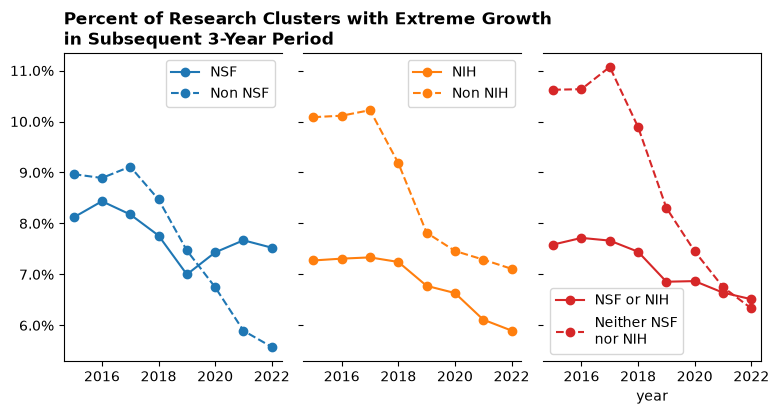

In [379]:
# Complete Data

fig, axs = plt.subplots(figsize=(9,4), ncols=3, sharey = True, sharex = True)
plt.subplots_adjust(wspace=0.1)

x = funding_eg_trend['forecast_year']
axs[0].plot(x, funding_eg_trend['frac_nsf_eg'], c = cset_colors[0], marker='o',
         label='NSF')
axs[0].plot(x, funding_eg_trend['frac_nonnsf_eg'], c = cset_colors[0], linestyle = '--', marker='o',
         label='Non NSF')
axs[1].plot(x, funding_eg_trend['frac_nih_eg'], c = cset_colors[1],  marker='o',
         label='NIH')
axs[1].plot(x, funding_eg_trend['frac_nonnih_eg'], c = cset_colors[1], linestyle = '--', marker='o',
         label='Non NIH')
axs[2].plot(x, funding_eg_trend['frac_nsfnih_eg'], c = cset_colors[3],  marker='o',
         label='NSF or NIH')
axs[2].plot(x, funding_eg_trend['frac_nonnsfnih_eg'], c = cset_colors[3], linestyle = '--', marker='o',
         label='Neither NSF\nnor NIH')

axs[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
#axs[0].set_xticks(range(2015,2023,1))
#axs[0].set_xlim([2014.5, 2024.5])
#axs[0].set_ylim([0,0.12])

axs[0].set_title('Percent of Research Clusters with Extreme Growth\nin Subsequent 3-Year Period', weight='bold', loc='left')
axs[2].set_xlabel('year')
axs[0].legend()
axs[1].legend()
axs[2].legend()
axs[0].spines['right'].set_visible(False)
axs[1].spines[['right','left']].set_visible(False)
axs[2].spines['left'].set_visible(False)

plt.savefig('../figures/yearly_extreme_growth.png', transparent=True, bbox_inches='tight')
plt.savefig('../figures/yearly_extreme_growth.pdf', bbox_inches='tight')

plt.show()

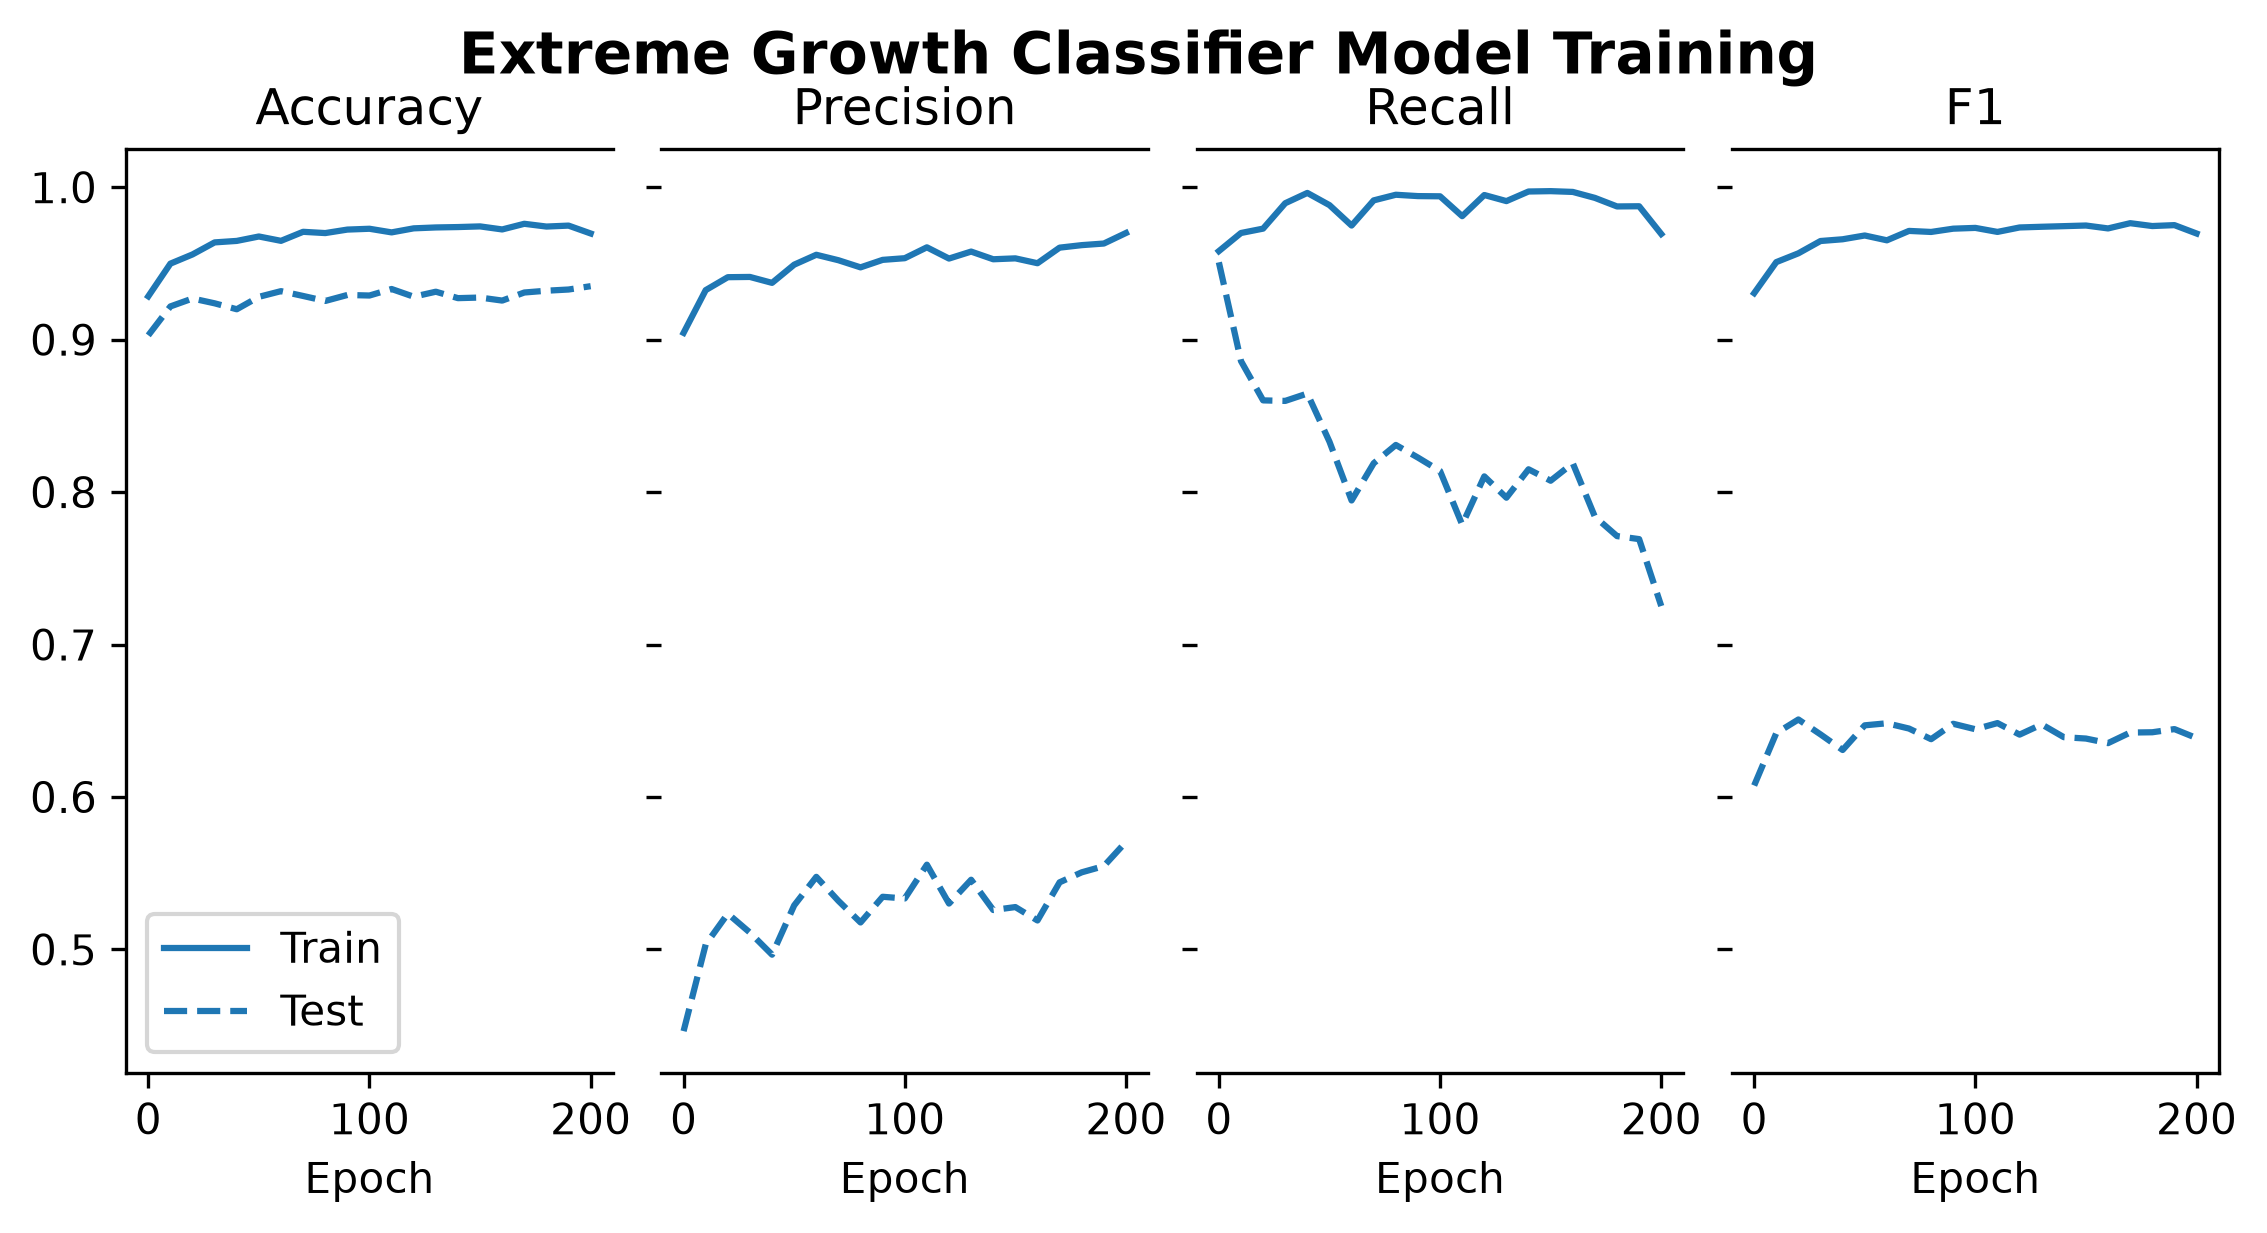

In [333]:
fig, axs = plt.subplots(figsize=(9,4), ncols=4, sharey = True, sharex = True, dpi=300)
plt.subplots_adjust(wspace=0.1)

for y1_text, y2_text, ax, title in zip(['accuracy_train','precision_train','recall_train','f1_train'],
                                    ['accuracy_test','precision_test','recall_test','f1_test'],
                                    axs,
                                       ['Accuracy','Precision','Recall','F1']
                                   ):
    
    y1 = history[y1_text]
    y2 = history[y2_text]
    ax.plot(history['epoch'], y1, c=cset_colors[0], label='Train')
    ax.plot(history['epoch'], y2, c=cset_colors[0], linestyle='--', label='Test')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.spines[['right','left']].set_visible(False)

    
axs[0].spines[['left']].set_visible(True)
axs[3].spines[['right']].set_visible(True)
#axs[3].set_xticks([i for i in range(1, 1+max([max(n['epoch']) for n in [nn1yr,nn2yr,nn3yr,nn4yr,nn5yr]]))])
axs[0].legend()
axs[0].set_xlim([-10,210])

plt.suptitle('Extreme Growth Classifier Model Training', fontsize=14, weight='bold')

plt.savefig('../figures/classifier_training_evals.png',transparent=True,bbox_inches='tight')
plt.savefig('../figures/classifier_training_evals.pdf',transparent=True,bbox_inches='tight')

plt.show()

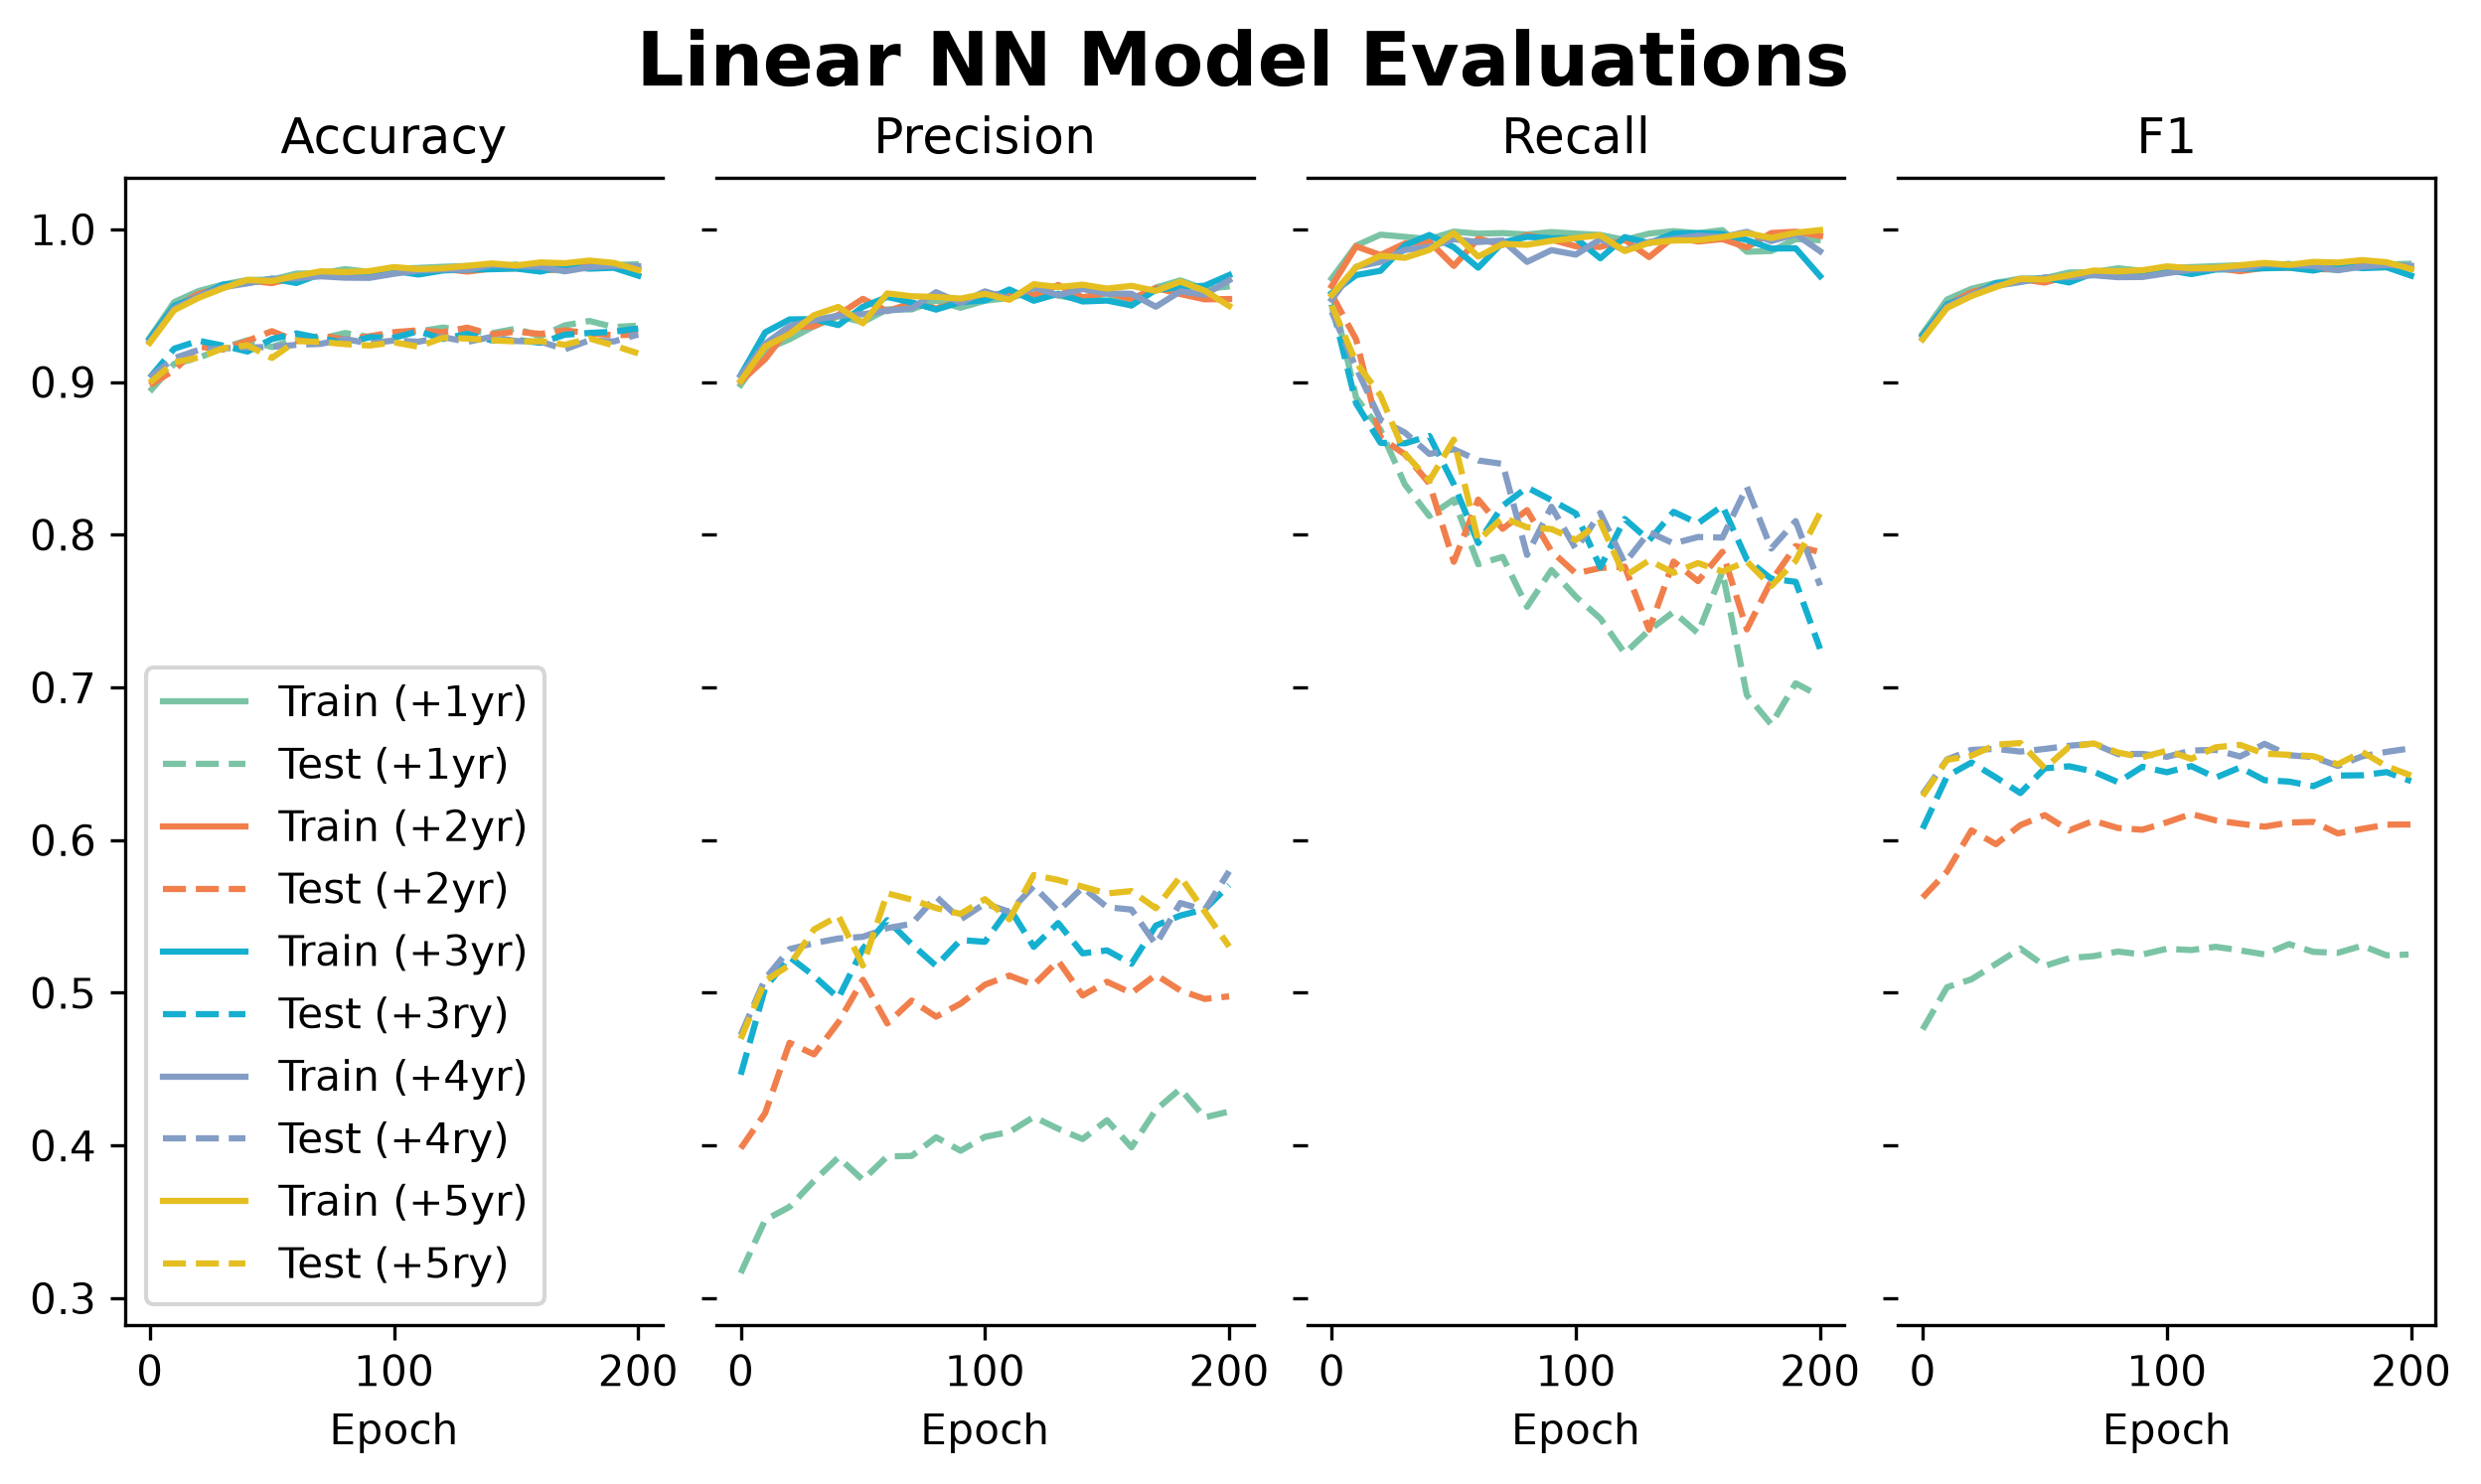

In [30]:
fig, axs = plt.subplots(figsize=(10,5), ncols=4, sharey = True, sharex = True, dpi=300)
plt.subplots_adjust(wspace=0.1)

for y1_text, y2_text, ax, title in zip(['accuracy_train','precision_train','recall_train','f1_train'],
                                    ['accuracy_test','precision_test','recall_test','f1_test'],
                                    axs,
                                       ['Accuracy','Precision','Recall','F1']
                                   ):
    
    y1 = history1[y1_text]
    y2 = history1[y2_text]
    ax.plot(history1['epoch'], y1, c=cset_colors[3], label='Train (+1yr)')
    ax.plot(history1['epoch'], y2, c=cset_colors[3], linestyle='--', label='Test (+1yr)')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.spines[['right','left']].set_visible(False)
    
    y1 = history2[y1_text]
    y2 = history2[y2_text]
    ax.plot(history2['epoch'], y1, c=cset_colors[4], label='Train (+2yr)')
    ax.plot(history2['epoch'], y2, c=cset_colors[4], linestyle='--', label='Test (+2yr)')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.spines[['right','left']].set_visible(False)
    
    y1 = history[y1_text]
    y2 = history[y2_text]
    ax.plot(history['epoch'], y1, c=cset_colors[5], label='Train (+3yr)')
    ax.plot(history['epoch'], y2, c=cset_colors[5], linestyle='--', label='Test (+3ry)')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.spines[['right','left']].set_visible(False)
    
    y1 = history4[y1_text]
    y2 = history4[y2_text]
    ax.plot(history4['epoch'], y1, c=cset_colors[6], label='Train (+4yr)')
    ax.plot(history4['epoch'], y2, c=cset_colors[6], linestyle='--', label='Test (+4ry)')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.spines[['right','left']].set_visible(False)
    
    y1 = history5[y1_text]
    y2 = history5[y2_text]
    ax.plot(history5['epoch'], y1, c=cset_colors[7], label='Train (+5yr)')
    ax.plot(history5['epoch'], y2, c=cset_colors[7], linestyle='--', label='Test (+5ry)')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.spines[['right','left']].set_visible(False)
    
axs[0].spines[['left']].set_visible(True)
axs[3].spines[['right']].set_visible(True)
#axs[3].set_xticks([i for i in range(1, 1+max([max(n['epoch']) for n in [nn1yr,nn2yr,nn3yr,nn4yr,nn5yr]]))])
axs[0].legend()
axs[0].set_xlim([-10,210])

plt.suptitle('Linear NN Model Evaluations', fontsize=18, weight='bold')

plt.show()

In [33]:
nn1yr = history1
nn2yr = history2
nn3yr = history
nn4yr = history4
nn5yr = history5
nn1yr['year'] = 1
nn2yr['year'] = 2
nn3yr['year'] = 3
nn4yr['year'] = 4
nn5yr['year'] = 5
nn_model_evals = pd.DataFrame(pd.concat([nn1yr.iloc[-1],nn2yr.iloc[-1],nn3yr.iloc[-1],nn4yr.iloc[-1],nn5yr.iloc[-1]], axis=1))
nn_model_evals = nn_model_evals.transpose().set_index('year')

full_model_evals = pd.read_json(f'../ML_models/finalProbitModels/full_model_evals_141features.jsonl',lines=True)
simple_model_evals = pd.read_json(f'../ML_models/finalProbitModels/simple_model_evals_48features.jsonl',lines=True)
current_model_evals = pd.read_json(f'../ML_models/finalProbitModels/current_model_evals_4features.jsonl',lines=True)
all_model_evals = pd.read_json(f'../ML_models/finalProbitModels/all_model_evals_141features.jsonl',lines=True)
pruned_model_evals = pd.read_json(f'../ML_models/finalProbitModels/pruned_model_evals_variablefeatures.jsonl',lines=True)

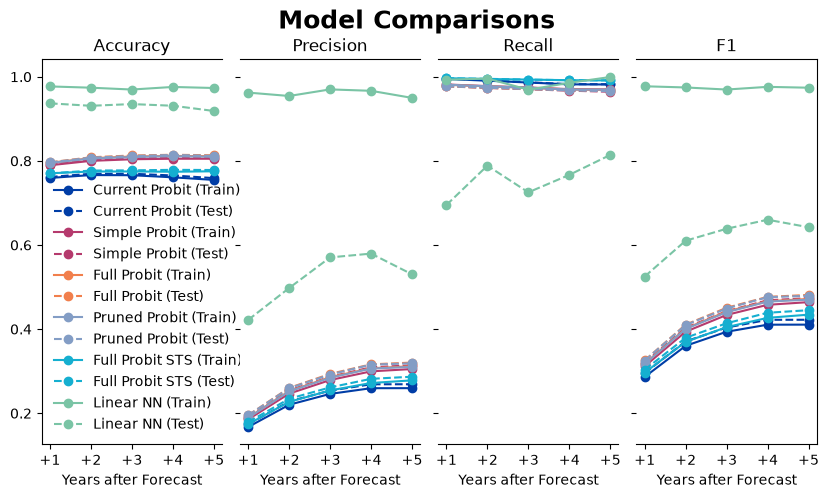

In [34]:
fig, axs = plt.subplots(figsize=(10,5), ncols=4, sharey = True, sharex = True)
plt.subplots_adjust(wspace=0.1)

for y1_text, y2_text, ax, title in zip(['accuracy_train','precision_train','recall_train','f1_train'],
                                    ['accuracy_test','precision_test','recall_test','f1_test'],
                                    axs,
                                       ['Accuracy','Precision','Recall','F1']
                                   ):
    years = range(1,6,1)
    y1 = simple_model_evals[y1_text]
    y2 = simple_model_evals[y2_text]
    y3 = full_model_evals[y1_text]
    y4 = full_model_evals[y2_text]
    y5 = nn_model_evals[y1_text]
    y6 = nn_model_evals[y2_text]
    y7 = current_model_evals[y1_text]
    y8 = current_model_evals[y2_text]
    y9 = all_model_evals[y1_text]
    y10 = all_model_evals[y2_text]
    y11 = pruned_model_evals[y1_text]
    y12 = pruned_model_evals[y2_text]
    
    ax.plot(years, y7, marker='o', c=cset_colors[1], label='Current Probit (Train)')
    ax.plot(years, y8, marker='o', c=cset_colors[1], linestyle='--', label='Current Probit (Test)')
    ax.plot(years, y1, marker='o', c=cset_colors[2], label='Simple Probit (Train)')
    ax.plot(years, y2, marker='o', c=cset_colors[2], linestyle='--', label='Simple Probit (Test)')
    ax.plot(years, y9, marker='o', c=cset_colors[4], label='Full Probit (Train)')
    ax.plot(years, y10, marker='o', c=cset_colors[4], linestyle='--', label='Full Probit (Test)')
    ax.plot(years, y11, marker='o', c=cset_colors[6], label='Pruned Probit (Train)')
    ax.plot(years, y12, marker='o', c=cset_colors[6], linestyle='--', label='Pruned Probit (Test)')
    ax.plot(years, y3, marker='o', c=cset_colors[5], label='Full Probit STS (Train)')
    ax.plot(years, y4, marker='o', c=cset_colors[5], linestyle='--', label='Full Probit STS (Test)')
    ax.plot(years, y5, marker='o', c=cset_colors[3], label='Linear NN (Train)')
    ax.plot(years, y6, marker='o', c=cset_colors[3], linestyle='--', label='Linear NN (Test)')
    
    ax.set_title(title)
    ax.set_xlabel('Years after Forecast')
    ax.spines[['right','left']].set_visible(False)

axs[3].set_xticks(years,[f'+{i}' for i in years])    
axs[0].spines[['left']].set_visible(True)
axs[3].spines[['right']].set_visible(True)
axs[0].legend(frameon=False)

plt.suptitle('Model Comparisons', fontsize=18, weight='bold')

plt.show()

In [35]:
for idx, row in pruned_model_evals.iterrows():
    print(f"{row['growth_year']}: {len(row['params'])} parameters")

EG_1Yr: 87 parameters
EG_2Yr: 86 parameters
EG_3Yr: 81 parameters
EG_4Yr: 92 parameters
EG_5Yr: 86 parameters


In [36]:
all_model_evals.iloc[2]

growth_year                                                   EG_3Yr
FY_max                                                          2022
accuracy_test                                               0.812855
precision_test                                              0.293492
recall_test                                                 0.970583
f1_test                                                     0.450698
accuracy_train                                              0.810412
precision_train                                             0.285771
recall_train                                                0.973967
f1_train                                                    0.441888
params             [0.502871072, 0.601636803, -0.3179207793, -0.3...
Name: 2, dtype: object

In [37]:
pruned_model_evals.iloc[2]

growth_year                                                   EG_3Yr
FY_max                                                          2022
accuracy_test                                               0.811531
precision_test                                              0.292035
recall_test                                                 0.970756
f1_test                                                     0.448998
accuracy_train                                              0.809066
precision_train                                             0.284325
recall_train                                                0.974055
f1_train                                                    0.440166
params             [0.5033608659000001, 0.6002211132, -0.32260350...
Name: 2, dtype: object

In [38]:
growth_2015 = all_cluster_data_predictions[all_cluster_data_predictions['forecast_year'] == 2015]
growth_2016 = all_cluster_data_predictions[all_cluster_data_predictions['forecast_year'] == 2016]
growth_2017 = all_cluster_data_predictions[all_cluster_data_predictions['forecast_year'] == 2017]
growth_2018 = all_cluster_data_predictions[all_cluster_data_predictions['forecast_year'] == 2018]
growth_2019 = all_cluster_data_predictions[all_cluster_data_predictions['forecast_year'] == 2019]
growth_2020 = all_cluster_data_predictions[all_cluster_data_predictions['forecast_year'] == 2020]
growth_2021 = all_cluster_data_predictions[all_cluster_data_predictions['forecast_year'] == 2021]
growth_2022 = all_cluster_data_predictions[all_cluster_data_predictions['forecast_year'] == 2022]
growth_2023 = all_cluster_data_predictions[all_cluster_data_predictions['forecast_year'] == 2023]
growth_2024 = all_cluster_data_predictions[all_cluster_data_predictions['forecast_year'] == 2024]

x_2015 = pd.concat([transforms[k](growth_2015[k]) for k in transforms.keys()], axis=1).values
x_2016 = pd.concat([transforms[k](growth_2016[k]) for k in transforms.keys()], axis=1).values
x_2017 = pd.concat([transforms[k](growth_2017[k]) for k in transforms.keys()], axis=1).values
x_2018 = pd.concat([transforms[k](growth_2018[k]) for k in transforms.keys()], axis=1).values
x_2019 = pd.concat([transforms[k](growth_2019[k]) for k in transforms.keys()], axis=1).values
x_2020 = pd.concat([transforms[k](growth_2020[k]) for k in transforms.keys()], axis=1).values
x_2021 = pd.concat([transforms[k](growth_2021[k]) for k in transforms.keys()], axis=1).values
x_2022 = pd.concat([transforms[k](growth_2022[k]) for k in transforms.keys()], axis=1).values
x_2023 = pd.concat([transforms[k](growth_2023[k]) for k in transforms.keys()], axis=1).values
x_2024 = pd.concat([transforms[k](growth_2024[k]) for k in transforms.keys()], axis=1).values

growth_2015['pred'] = find_model_predictions(x_2015)
growth_2016['pred'] = find_model_predictions(x_2016)
growth_2017['pred'] = find_model_predictions(x_2017)
growth_2018['pred'] = find_model_predictions(x_2018)
growth_2019['pred'] = find_model_predictions(x_2019)
growth_2020['pred'] = find_model_predictions(x_2020)
growth_2021['pred'] = find_model_predictions(x_2021)
growth_2022['pred'] = find_model_predictions(x_2022)
growth_2023['pred'] = find_model_predictions(x_2023)
growth_2024['pred'] = find_model_predictions(x_2024)

100%|█████████████████████████████████████| 9160/9160 [00:01<00:00, 4937.64it/s]


In [39]:
yearly_stats = pd.DataFrame([
    {
        'FY':2015,
        'EG':sum(growth_2015['EG_3Yr']),
        'EG_predicted':sum((growth_2015['EG_3Yr'] == growth_2015['pred']) & (growth_2015['EG_3Yr'] == 1)),
        'EG_notpredicted':sum((growth_2015['EG_3Yr'] != growth_2015['pred']) & (growth_2015['EG_3Yr'] == 1)),
        'noEG_predicted':sum((growth_2015['EG_3Yr'] != growth_2015['pred']) & (growth_2015['pred'] == 1)),
        'noEGyet_predicted':0
    },
    {
        'FY':2016,
        'EG':sum(growth_2016['EG_3Yr']),
        'EG_predicted':sum((growth_2016['EG_3Yr'] == growth_2016['pred']) & (growth_2016['EG_3Yr'] == 1)),
        'EG_notpredicted':sum((growth_2016['EG_3Yr'] != growth_2016['pred']) & (growth_2016['EG_3Yr'] == 1)),
        'noEG_predicted':sum((growth_2016['EG_3Yr'] != growth_2016['pred']) & (growth_2016['pred'] == 1)),
        'noEGyet_predicted':0
    },
    {
        'FY':2017,
        'EG':sum(growth_2017['EG_3Yr']),
        'EG_predicted':sum((growth_2017['EG_3Yr'] == growth_2017['pred']) & (growth_2017['EG_3Yr'] == 1)),
        'EG_notpredicted':sum((growth_2017['EG_3Yr'] != growth_2017['pred']) & (growth_2017['EG_3Yr'] == 1)),
        'noEG_predicted':sum((growth_2017['EG_3Yr'] != growth_2017['pred']) & (growth_2017['pred'] == 1)),
        'noEGyet_predicted':0
    },
    {
        'FY':2018,
        'EG':sum(growth_2018['EG_3Yr']),
        'EG_predicted':sum((growth_2018['EG_3Yr'] == growth_2018['pred']) & (growth_2018['EG_3Yr'] == 1)),
        'EG_notpredicted':sum((growth_2018['EG_3Yr'] != growth_2018['pred']) & (growth_2018['EG_3Yr'] == 1)),
        'noEG_predicted':sum((growth_2018['EG_3Yr'] != growth_2018['pred']) & (growth_2018['pred'] == 1)),
        'noEGyet_predicted':0
    },
    {
        'FY':2019,
        'EG':sum(growth_2019['EG_3Yr']),
        'EG_predicted':sum((growth_2019['EG_3Yr'] == growth_2019['pred']) & (growth_2019['EG_3Yr'] == 1)),
        'EG_notpredicted':sum((growth_2019['EG_3Yr'] != growth_2019['pred']) & (growth_2019['EG_3Yr'] == 1)),
        'noEG_predicted':sum((growth_2019['EG_3Yr'] != growth_2019['pred']) & (growth_2019['pred'] == 1)),
        'noEGyet_predicted':0
    },
    {
        'FY':2020,
        'EG':sum(growth_2020['EG_3Yr']),
        'EG_predicted':sum((growth_2020['EG_3Yr'] == growth_2020['pred']) & (growth_2020['EG_3Yr'] == 1)),
        'EG_notpredicted':sum((growth_2020['EG_3Yr'] != growth_2020['pred']) & (growth_2020['EG_3Yr'] == 1)),
        'noEG_predicted':sum((growth_2020['EG_3Yr'] != growth_2020['pred']) & (growth_2020['pred'] == 1)),
        'noEGyet_predicted':0
    },
    {
        'FY':2021,
        'EG':sum(growth_2021['EG_3Yr']),
        'EG_predicted':sum((growth_2021['EG_3Yr'] == growth_2021['pred']) & (growth_2021['EG_3Yr'] == 1)),
        'EG_notpredicted':sum((growth_2021['EG_3Yr'] != growth_2021['pred']) & (growth_2021['EG_3Yr'] == 1)),
        'noEG_predicted':sum((growth_2021['EG_3Yr'] != growth_2021['pred']) & (growth_2021['pred'] == 1)),
        'noEGyet_predicted':0
    },
    {
        'FY':2022,
        'EG':sum(growth_2022['EG_3Yr']),
        'EG_predicted':sum((growth_2022['EG_3Yr'] == growth_2022['pred']) & (growth_2022['EG_3Yr'] == 1)),
        'EG_notpredicted':sum((growth_2022['EG_3Yr'] != growth_2022['pred']) & (growth_2022['EG_3Yr'] == 1)),
        'noEG_predicted':sum((growth_2022['EG_3Yr'] != growth_2022['pred']) & (growth_2022['pred'] == 1)),
        'noEGyet_predicted':0
    },
    {
        'FY':2023,
        'EG':sum(growth_2022['EG_2Yr']),
        'EG_predicted':sum((growth_2023['EG_2Yr'] == growth_2023['pred']) & (growth_2023['EG_2Yr'] == 1)),
        'EG_notpredicted':sum((growth_2023['EG_2Yr'] != growth_2023['pred']) & (growth_2023['EG_2Yr'] == 1)),
        'noEG_predicted': 0,
        'noEGyet_predicted':sum((growth_2023['EG_2Yr'] != growth_2023['pred']) & (growth_2023['pred'] == 1)),
    },
    {
        'FY':2024,
        'EG':sum(growth_2022['EG_1Yr']),
        'EG_predicted':sum((growth_2024['EG_1Yr'] == growth_2024['pred']) & (growth_2024['EG_1Yr'] == 1)),
        'EG_notpredicted':sum((growth_2024['EG_1Yr'] != growth_2024['pred']) & (growth_2024['EG_1Yr'] == 1)),
        'noEG_predicted':0,
        'noEGyet_predicted':sum((growth_2024['EG_1Yr'] != growth_2024['pred']) & (growth_2024['pred'] == 1)),
    },
    {
        'FY':2025,
        'EG':0,
        'EG_predicted':0,
        'EG_notpredicted':0,
        'noEG_predicted':0,
        'noEGyet_predicted':sum(growth_features_2025['pred']),
    }
])


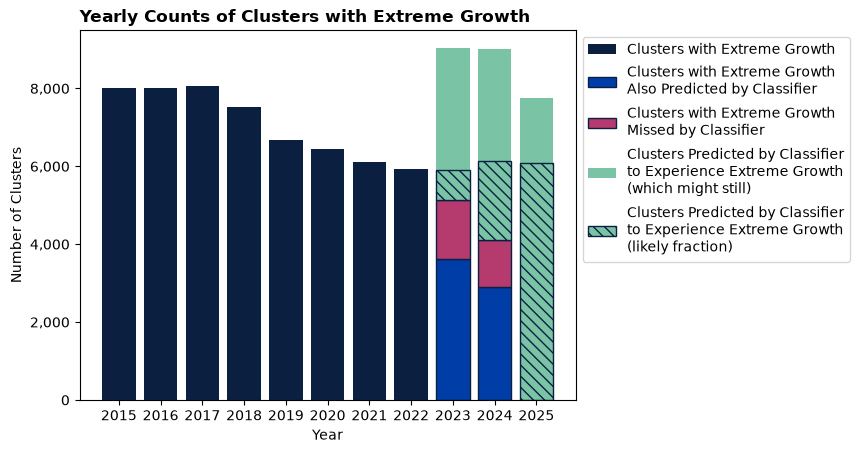

In [40]:
plt.bar(yearly_stats['FY'], yearly_stats['EG'], color=cset_colors[0],
       label='Clusters with Extreme Growth')

plt.bar(yearly_stats['FY'][-3:], yearly_stats['EG_predicted'][-3:], color=cset_colors[1], edgecolor=cset_colors[0],
       label='Clusters with Extreme Growth\nAlso Predicted by Classifier')

bottom = yearly_stats['EG_predicted'] 
plt.bar(yearly_stats['FY'][-3:], yearly_stats['EG_notpredicted'][-3:], bottom = bottom[-3:], edgecolor=cset_colors[0],
        color=cset_colors[2],
       label='Clusters with Extreme Growth\nMissed by Classifier')

bottom = yearly_stats['EG_predicted'] + yearly_stats['EG_notpredicted']
plt.bar(yearly_stats['FY'], yearly_stats['noEGyet_predicted'], bottom = bottom,
        color=cset_colors[3],
       label='Clusters Predicted by Classifier\nto Experience Extreme Growth\n(which might still)')

precision = history.iloc[-1]['precision_test']
recall = history.iloc[-1]['recall_test']

bottom = yearly_stats['EG_predicted'] + yearly_stats['EG_notpredicted']
y_remaining = [max(e,0) for e in precision*(yearly_stats['noEGyet_predicted'] + yearly_stats['EG_predicted'])/recall - yearly_stats['EG_predicted'] - yearly_stats['EG_notpredicted']]
plt.bar(yearly_stats['FY'][-3:], #yearly_stats['noEGyet_predicted'],
        y_remaining[-3:], 
        bottom = bottom[-3:],
        color=cset_colors[3], hatch = '\\\\\\', edgecolor=cset_colors[0],
       label='Clusters Predicted by Classifier\nto Experience Extreme Growth\n(likely fraction)')

plt.ylabel('Number of Clusters')
plt.xlabel('Year')
plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.xticks(range(2015,2026,1))

plt.title('Yearly Counts of Clusters with Extreme Growth', weight='bold', loc='left')

plt.show()

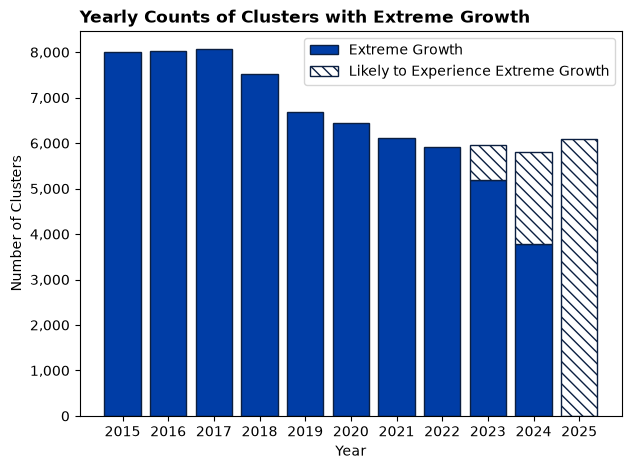

In [41]:
plt.figure(figsize=(7,5))
plt.bar(yearly_stats['FY'], yearly_stats['EG'], color=cset_colors[1], edgecolor=cset_colors[0],
       label='Extreme Growth')

precision = history.iloc[-1]['precision_test']
recall = history.iloc[-1]['recall_test']

bottom = yearly_stats['EG']
y_remaining = [max(e,0) for e in precision*(yearly_stats['noEGyet_predicted'] + yearly_stats['EG_predicted'])/recall - yearly_stats['EG_predicted'] - yearly_stats['EG_notpredicted']]
plt.bar(yearly_stats['FY'][-3:], #yearly_stats['noEGyet_predicted'],
        y_remaining[-3:], 
        bottom = bottom[-3:],
        color='white', hatch = '\\\\\\', edgecolor=cset_colors[0],
       label='Likely to Experience Extreme Growth')

plt.ylabel('Number of Clusters')
plt.xlabel('Year')
plt.legend()
#plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.xticks(range(2015,2026,1))

plt.title('Yearly Counts of Clusters with Extreme Growth', weight='bold', loc='left')

plt.savefig('../figures/extreme_growth_yearly_counts.png', transparent=True, bbox_inches='tight')
plt.savefig('../figures/extreme_growth_yearly_counts.pdf', bbox_inches='tight')

plt.show()

In [363]:
funding_eg_pred_trend = []
for forecast_year, growth_df in zip([2023,2024,2025],[growth_2023,growth_2024,growth_features_2025]):
    df_nsftmp = pd.merge(funder_yearly_flag[['cluster_id',f'n_nsf{forecast_year}']],growth_df[['cluster_id','pred']])
    df_nihtmp = pd.merge(funder_yearly_flag[['cluster_id',f'n_nih{forecast_year}']],growth_df[['cluster_id','pred']])
    df_nsfnihtmp = pd.merge(funder_yearly_flag[['cluster_id',f'n_nsfnih{forecast_year}']],growth_df[['cluster_id','pred']])
    
    # NSF evals
    df_nsftmp['is_nsf'] = df_nsftmp[f'n_nsf{forecast_year}'] > 0
    frac_nsf_eg = sum(df_nsftmp['is_nsf'] & (df_nsftmp['pred'] == 1)) / sum(df_nsftmp['is_nsf'])
    frac_nonnsf_eg = sum((~df_nsftmp['is_nsf']) & (df_nsftmp['pred'] == 1)) / sum(~df_nsftmp['is_nsf'])

    # NIH evals
    df_nihtmp['is_nih'] = df_nihtmp[f'n_nih{forecast_year}'] > 0
    frac_nih_eg = sum(df_nihtmp['is_nih'] & (df_nihtmp['pred'] == 1)) / sum(df_nihtmp['is_nih'])
    frac_nonnih_eg = sum((~df_nihtmp['is_nih']) & (df_nihtmp['pred'] == 1)) / sum(~df_nihtmp['is_nih'])

    # NSF/NIH evals
    df_nsfnihtmp['is_nsfnih'] = df_nsfnihtmp[f'n_nsfnih{forecast_year}'] > 0
    frac_nsfnih_eg = sum(df_nsfnihtmp['is_nsfnih'] & (df_nsfnihtmp['pred'] == 1)) / sum(df_nsfnihtmp['is_nsfnih'])
    frac_nonnsfnih_eg = sum((~df_nsfnihtmp['is_nsfnih']) & (df_nsfnihtmp['pred'] == 1)) / sum(~df_nsfnihtmp['is_nsfnih'])

    funding_eg_pred_trend.append({
        'forecast_year':forecast_year,
        'frac_nsf_eg':frac_nsf_eg,
        'frac_nonnsf_eg':frac_nonnsf_eg,
        'frac_nih_eg':frac_nih_eg,
        'frac_nonnih_eg':frac_nonnih_eg,
        'frac_nsfnih_eg':frac_nsfnih_eg,
        'frac_nonnsfnih_eg':frac_nonnsfnih_eg,
    })
    
funding_eg_pred_trend = pd.DataFrame(funding_eg_pred_trend)

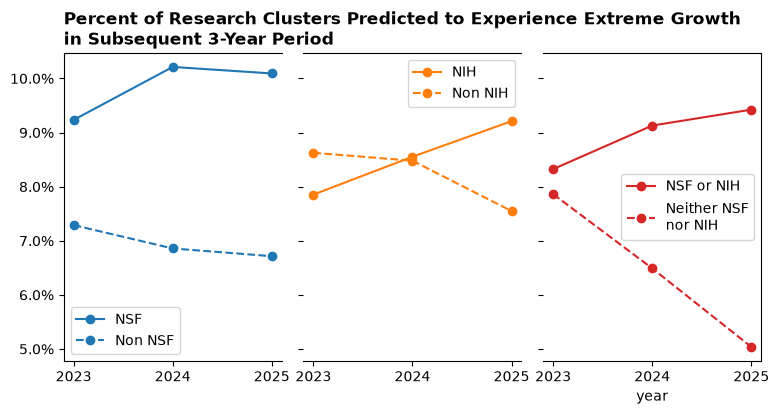

In [378]:
# Complete Data

fig, axs = plt.subplots(figsize=(9,4), ncols=3, sharey = True, sharex = True)
plt.subplots_adjust(wspace=0.1)

x = funding_eg_pred_trend['forecast_year']
axs[0].plot(x, funding_eg_pred_trend['frac_nsf_eg'], c = cset_colors[0], marker='o',
         label='NSF')
axs[0].plot(x, funding_eg_pred_trend['frac_nonnsf_eg'], c = cset_colors[0], linestyle = '--', marker='o',
         label='Non NSF')
axs[1].plot(x, funding_eg_pred_trend['frac_nih_eg'], c = cset_colors[1],  marker='o',
         label='NIH')
axs[1].plot(x, funding_eg_pred_trend['frac_nonnih_eg'], c = cset_colors[1], linestyle = '--', marker='o',
         label='Non NIH')
axs[2].plot(x, funding_eg_pred_trend['frac_nsfnih_eg'], c = cset_colors[3],  marker='o',
         label='NSF or NIH')
axs[2].plot(x, funding_eg_pred_trend['frac_nonnsfnih_eg'], c = cset_colors[3], linestyle = '--', marker='o',
         label='Neither NSF\nnor NIH')

axs[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

axs[0].set_title('Percent of Research Clusters Predicted to Experience Extreme Growth\nin Subsequent 3-Year Period', weight='bold', loc='left')
axs[2].set_xlabel('year')
axs[0].legend()
axs[1].legend()
axs[2].legend()
axs[0].spines['right'].set_visible(False)
axs[1].spines[['right','left']].set_visible(False)
axs[2].spines['left'].set_visible(False)

axs[0].set_xticks([2023,2024,2025])

plt.savefig('../figures/yearly_extreme_growth_pred.png', transparent=True, bbox_inches='tight')
plt.savefig('../figures/yearly_extreme_growth_pred.pdf', bbox_inches='tight')

plt.show()

# Field Breakdowns

In [323]:
nsf_clusters = all_cluster_data[all_cluster_data['n_papers_nsf'] > 0]
nih_clusters = all_cluster_data[all_cluster_data['n_papers_nih'] > 0]
non_nsf_clusters = all_cluster_data[all_cluster_data['n_papers_nsf'] == 0]
non_nih_clusters = all_cluster_data[all_cluster_data['n_papers_nih'] == 0]
nsf_nih_clusters = all_cluster_data[(all_cluster_data['n_papers_nsf'] > 0) + (all_cluster_data['n_papers_nih'] > 0)]
non_nsf_nih_clusters = all_cluster_data[(all_cluster_data['n_papers_nsf'] == 0) & (all_cluster_data['n_papers_nih'] == 0)]

In [324]:
print(f"There are {len(nsf_clusters):,.0f} NSF clusters")

There are 47,489 NSF clusters


In [325]:
print(f"There are {len(nih_clusters):,.0f} NIH clusters")

There are 49,933 NIH clusters


In [326]:
print(f"There are {len(nsf_nih_clusters):,.0f} NSF/NIH clusters")

There are 71,508 NSF/NIH clusters


In [208]:
NSF_stats = pd.DataFrame([
    {
        'class_art':k,
        'frac_EG_nsf':sum((nsf_clusters['pred']) & (nsf_clusters['class_art'] == k))/sum(nsf_clusters['class_art'] == k),
        'n_EG_nsf':sum((nsf_clusters['pred']) & (nsf_clusters['class_art'] == k)),
        'n_nsf':sum(nsf_clusters['class_art'] == k),
        'frac_EG':sum((non_nsf_clusters['pred']) & (non_nsf_clusters['class_art'] == k))/sum(non_nsf_clusters['class_art'] == k),
        'n_EG':sum((non_nsf_clusters['pred']) & (non_nsf_clusters['class_art'] == k)),
        'n_nonnsf':sum(non_nsf_clusters['class_art'] == k),
        'frac_EG_all':sum((all_cluster_data['pred']) & (all_cluster_data['class_art'] == k))/sum(all_cluster_data['class_art'] == k),
        'n_EG_all':sum((all_cluster_data['pred']) & (all_cluster_data['class_art'] == k)),
        'n_all':sum(all_cluster_data['class_art'] == k)
    }
    for k in mos_color_dict.keys()
])
NSF_stats['frac_of_nsf'] = NSF_stats['n_nsf']/sum(NSF_stats['n_nsf'])

In [209]:
NIH_stats = pd.DataFrame([
    {
        'class_art':k,
        'frac_EG_nih':sum((nih_clusters['pred']) & (nih_clusters['class_art'] == k))/sum(nih_clusters['class_art'] == k),
        'n_EG_nih':sum((nih_clusters['pred']) & (nih_clusters['class_art'] == k)),
        'n_nih':sum(nih_clusters['class_art'] == k),
        'frac_EG':sum((non_nih_clusters['pred']) & (non_nih_clusters['class_art'] == k))/sum(non_nih_clusters['class_art'] == k),
        'n_EG':sum((non_nih_clusters['pred']) & (non_nih_clusters['class_art'] == k)),
        'n_nonnih':sum(non_nih_clusters['class_art'] == k),
        'frac_EG_all':sum((all_cluster_data['pred']) & (all_cluster_data['class_art'] == k))/sum(all_cluster_data['class_art'] == k),
        'n_EG_all':sum((all_cluster_data['pred']) & (all_cluster_data['class_art'] == k)),
        'n_all':sum(all_cluster_data['class_art'] == k)
    }
    for k in mos_color_dict.keys()
])
NIH_stats['frac_of_nih'] = NIH_stats['n_nih']/sum(NIH_stats['n_nih'])

In [210]:
NSF_NIH_stats = pd.DataFrame([
    {
        'class_art':k,
        'frac_EG_nsf_nih':sum((nsf_nih_clusters['pred']) & (nsf_nih_clusters['class_art'] == k))/sum(nsf_nih_clusters['class_art'] == k),
        'n_EG_nsf_nih':sum((nsf_nih_clusters['pred']) & (nsf_nih_clusters['class_art'] == k)),
        'n_nsf_nih':sum(nsf_nih_clusters['class_art'] == k),
        'frac_EG':sum((non_nsf_nih_clusters['pred']) & (non_nsf_nih_clusters['class_art'] == k))/sum(non_nsf_nih_clusters['class_art'] == k),
        'n_EG':sum((non_nsf_nih_clusters['pred']) & (non_nsf_nih_clusters['class_art'] == k)),
        'n_nonnsfnih':sum(non_nsf_nih_clusters['class_art'] == k),
        'frac_EG_all':sum((all_cluster_data['pred']) & (all_cluster_data['class_art'] == k))/sum(all_cluster_data['class_art'] == k),
        'n_EG_all':sum((all_cluster_data['pred']) & (all_cluster_data['class_art'] == k)),
        'n_all':sum(all_cluster_data['class_art'] == k)
    }
    for k in mos_color_dict.keys()
])
NSF_NIH_stats['frac_of_nonnsfnih'] = NSF_NIH_stats['n_nonnsfnih'] / sum(NSF_NIH_stats['n_nonnsfnih'])

10.1% of NSF clusters expected to experience extreme growth, compared to 6.7% of non-NSF clusters


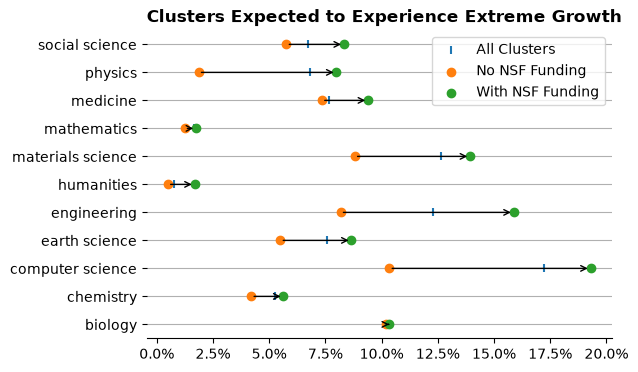

In [327]:
print(f"{100*sum(nsf_clusters['pred'])/len(nsf_clusters):.1f}% of NSF clusters expected to experience extreme growth, compared to {100*sum(non_nsf_clusters['pred'])/len(non_nsf_clusters):.1f}% of non-NSF clusters")

plt.figure(figsize=(6,4))

plt.scatter(NSF_stats['frac_EG_all'], NSF_stats.index, marker='|', zorder = 2,
            c=cset_colors[0], label='All Clusters')
plt.scatter(NSF_stats['frac_EG'], NSF_stats.index,  zorder = 2,
            c=cset_colors[1], label='No NSF Funding')
plt.scatter(NSF_stats['frac_EG_nsf'], NSF_stats.index,  zorder = 2,
            c=cset_colors[2], label='With NSF Funding')
for idx, row in NSF_stats.iterrows():
    plt.gca().annotate("", xytext=(row['frac_EG'], idx), xy=(row['frac_EG_nsf'], idx),
            arrowprops=dict(arrowstyle="->"))

plt.yticks(NSF_stats.index, NSF_stats['class_art'])
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.legend()

plt.title("Clusters Expected to Experience Extreme Growth", loc='left', weight='bold')

plt.gca().spines[['top','right','left']].set_visible(False)
plt.grid(axis='y')

plt.show()

9.2% of NIH clusters expected to experience extreme growth, compared to 7.5% of non-NIH clusters


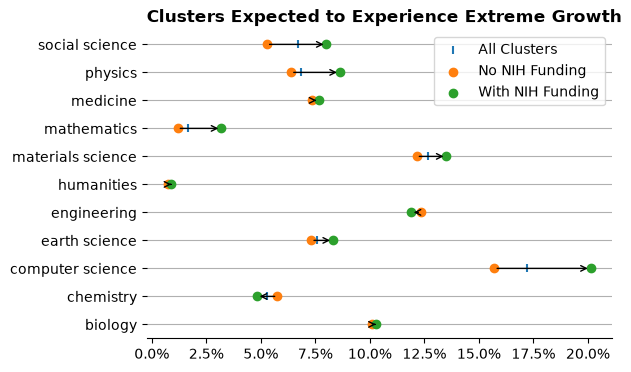

In [328]:
print(f"{100*sum(nih_clusters['pred'])/len(nih_clusters):.1f}% of NIH clusters expected to experience extreme growth, compared to {100*sum(non_nih_clusters['pred'])/len(non_nih_clusters):.1f}% of non-NIH clusters")


plt.figure(figsize=(6,4))

plt.scatter(NSF_stats['frac_EG_all'], NSF_stats.index, marker='|', c=cset_colors[0], label='All Clusters')
plt.scatter(NIH_stats['frac_EG'], NIH_stats.index, c=cset_colors[1], zorder=2,
            label='No NIH Funding')
plt.scatter(NIH_stats['frac_EG_nih'], NIH_stats.index, zorder=2,
            c=cset_colors[2], label='With NIH Funding')
for idx, row in NIH_stats.iterrows():
    plt.gca().annotate("", xytext=(row['frac_EG'], idx), xy=(row['frac_EG_nih'], idx),
            arrowprops=dict(arrowstyle="->"))

plt.yticks(NIH_stats.index, NIH_stats['class_art'])
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.legend()

plt.title("Clusters Expected to Experience Extreme Growth", loc='left', weight='bold')

plt.gca().spines[['top','right','left']].set_visible(False)
plt.grid(axis='y')

plt.show()

9.4% of NSF/NIH clusters expected to experience extreme growth, compared to 5.0% of non-NSF/NIH clusters


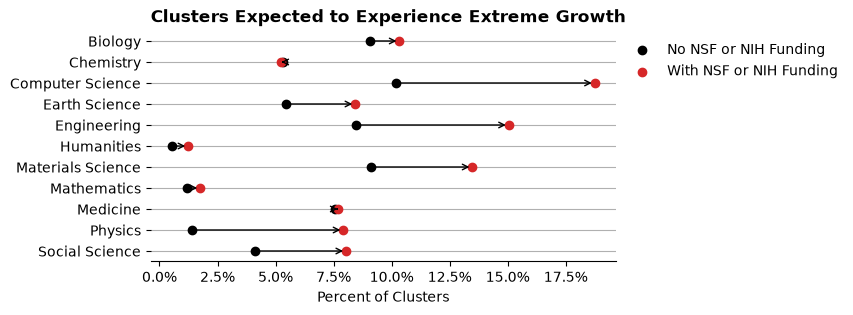

In [377]:
print(f"{100*sum(nsf_nih_clusters['pred'])/len(nsf_nih_clusters):.1f}% of NSF/NIH clusters expected to experience extreme growth, compared to {100*sum(non_nsf_nih_clusters['pred'])/len(non_nsf_nih_clusters):.1f}% of non-NSF/NIH clusters")


plt.figure(figsize=(6,3))


#plt.scatter(NSF_NIH_stats['frac_EG_all'], NSF_stats.index, marker='|', zorder = 3,
#            c=cset_colors[0], label='All Clusters')
plt.scatter(NSF_NIH_stats['frac_EG'], NSF_NIH_stats.index, zorder = 2,
            c='black', label='No NSF or NIH Funding')
plt.scatter(NSF_NIH_stats['frac_EG_nsf_nih'], NSF_NIH_stats.index, zorder = 2,
            c=cset_colors[3], label='With NSF or NIH Funding')
for idx, row in NSF_NIH_stats.iterrows():
    plt.gca().annotate("", xytext=(row['frac_EG'], idx), xy=(row['frac_EG_nsf_nih'], idx),
            arrowprops=dict(arrowstyle="->"))

plt.yticks(NSF_NIH_stats.index, [c.title() for c in NSF_NIH_stats['class_art'].values])
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.legend(bbox_to_anchor=(1, 1), loc="upper left", frameon=False)

plt.title("Clusters Expected to Experience Extreme Growth", loc='left', weight='bold')

plt.gca().spines[['top','right','left']].set_visible(False)
plt.grid(axis='y')
plt.gca().invert_yaxis()

plt.xlabel('Percent of Clusters')

plt.savefig('../figures/field_extreme_growth.png', transparent=True, bbox_inches='tight')
plt.savefig('../figures/field_extreme_growth.pdf', transparent=True, bbox_inches='tight')

plt.show()

In [277]:
NSF_NIH_stats[(NSF_NIH_stats['class_art'] == 'computer science') + (NSF_NIH_stats['class_art'] == 'humanities')]

,class_art,frac_EG_nsf_nih,n_EG_nsf_nih,n_nsf_nih,frac_EG,n_EG,n_nonnsfnih,frac_EG_all,n_EG_all,n_all,frac_of_nonnsfnih
2,computer science,0.187431,1020,5442,0.101796,119,1169,0.172289,1139,6611,0.058307
5,humanities,0.012308,16,1300,0.005335,14,2624,0.007645,30,3924,0.130879


In [289]:
field_compare = pd.merge(NSF_NIH_stats[['class_art','frac_EG']], NSF_NIH_stats[['class_art','frac_EG_nsf_nih']], on='class_art')
field_compare['ratio'] = field_compare['frac_EG_nsf_nih']/field_compare['frac_EG']
field_compare.sort_values('ratio')

,class_art,frac_EG,frac_EG_nsf_nih,ratio
1,chemistry,0.053393,0.052521,0.983668
8,medicine,0.075397,0.076708,1.017387
0,biology,0.090539,0.103302,1.140970
6,materials science,0.091245,0.134728,1.476541
7,mathematics,0.011682,0.017478,1.496079
3,earth science,0.054302,0.084246,1.551438
4,engineering,0.084665,0.150402,1.776444
2,computer science,0.101796,0.187431,1.841235
10,social science,0.041062,0.080312,1.955870
5,humanities,0.005335,0.012308,2.306813


9.4% of NSF/NIH clusters expected to experience extreme growth, compared to 5.0% of non-NSF/NIH clusters


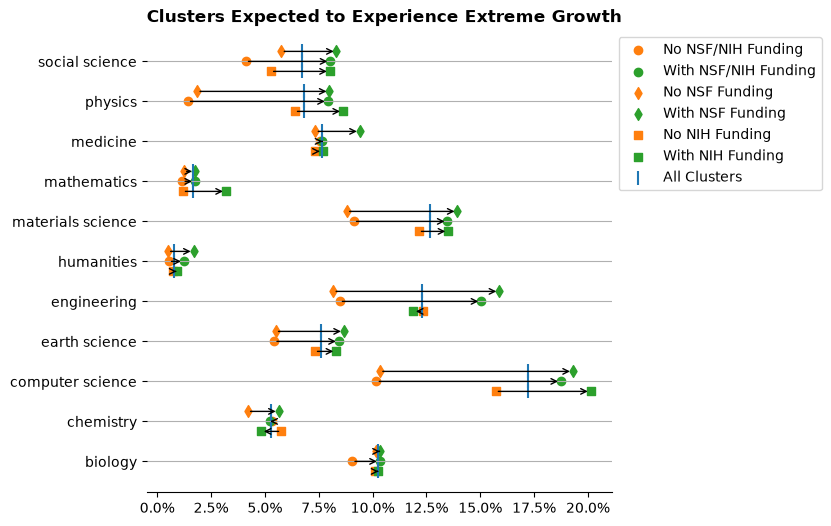

In [380]:
print(f"{100*sum(nsf_nih_clusters['pred'])/len(nsf_nih_clusters):.1f}% of NSF/NIH clusters expected to experience extreme growth, compared to {100*sum(non_nsf_nih_clusters['pred'])/len(non_nsf_nih_clusters):.1f}% of non-NSF/NIH clusters")


plt.figure(figsize=(6,6))

plt.scatter(NSF_NIH_stats['frac_EG'], NSF_NIH_stats.index, 
            c=cset_colors[1], label='No NSF/NIH Funding')
plt.scatter(NSF_NIH_stats['frac_EG_nsf_nih'], NSF_NIH_stats.index, 
            c=cset_colors[2], label='With NSF/NIH Funding')
plt.scatter(NSF_stats['frac_EG_all'], NSF_stats.index, marker='|', s=100,
            c=cset_colors[0])
for idx, row in NSF_NIH_stats.iterrows():
    plt.gca().annotate("", xytext=(row['frac_EG'], idx), xy=(row['frac_EG_nsf_nih'], idx),
            arrowprops=dict(arrowstyle="->"))
    
width = 0.25
plt.scatter(NSF_stats['frac_EG'], NSF_stats.index+width, marker='d', 
            c=cset_colors[1], label='No NSF Funding')
plt.scatter(NSF_stats['frac_EG_nsf'], NSF_stats.index+width, marker='d',
            c=cset_colors[2], label='With NSF Funding')
plt.scatter(NSF_stats['frac_EG_all'], NSF_stats.index+width, marker='|', s=100,
            c=cset_colors[0])
for idx, row in NSF_stats.iterrows():
    plt.gca().annotate("", xytext=(row['frac_EG'], idx+width), xy=(row['frac_EG_nsf'], idx+width),
            arrowprops=dict(arrowstyle="->"))
    
width = -0.25
plt.scatter(NIH_stats['frac_EG'], NIH_stats.index+width, marker='s', 
            c=cset_colors[1], label='No NIH Funding')
plt.scatter(NIH_stats['frac_EG_nih'], NIH_stats.index+width, marker='s', 
            c=cset_colors[2], label='With NIH Funding')
plt.scatter(NIH_stats['frac_EG_all'], NIH_stats.index+width, marker='|', s=100,
            c=cset_colors[0], label='All Clusters')
for idx, row in NIH_stats.iterrows():
    plt.gca().annotate("", xytext=(row['frac_EG'], idx+width), xy=(row['frac_EG_nih'], idx+width),
            arrowprops=dict(arrowstyle="->"))

plt.grid(axis='y')

plt.yticks(NSF_NIH_stats.index, NSF_NIH_stats['class_art'])
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.legend(bbox_to_anchor=(1, 1), loc="upper left")

plt.title("Clusters Expected to Experience Extreme Growth", loc='left', weight='bold')
plt.gca().spines[['top','right','left']].set_visible(False)

plt.show()

In [215]:
print(f"Overall, {100*sum(all_cluster_data['pred'])/len(all_cluster_data):.1f}% of clusters are expected to have extreme growth")

Overall, 8.5% of clusters are expected to have extreme growth


# Merged Corpus Counts

In [58]:
query_text = f"""
WITH
age_articles AS ( #Getting the age of all articles in clusters, keeping 15 yr cutoff
  SELECT
    merged_id,
    cluster_id,
    year
  FROM map_of_science.cluster_assignment
  INNER JOIN literature.papers USING(merged_id)
),
article_counts AS (
  SELECT
    year,
    COUNT(DISTINCT merged_id) AS n_articles
  FROM age_articles
  GROUP BY year
  ORDER BY year DESC
)

SELECT
  year,
  n_articles
FROM article_counts
WHERE (year >= 2000) AND (year < 2026)
ORDER BY year
"""

query = client.query(query_text)
yearly_counts = pd.DataFrame([{k:row[k] for k in row.keys()} for row in query])

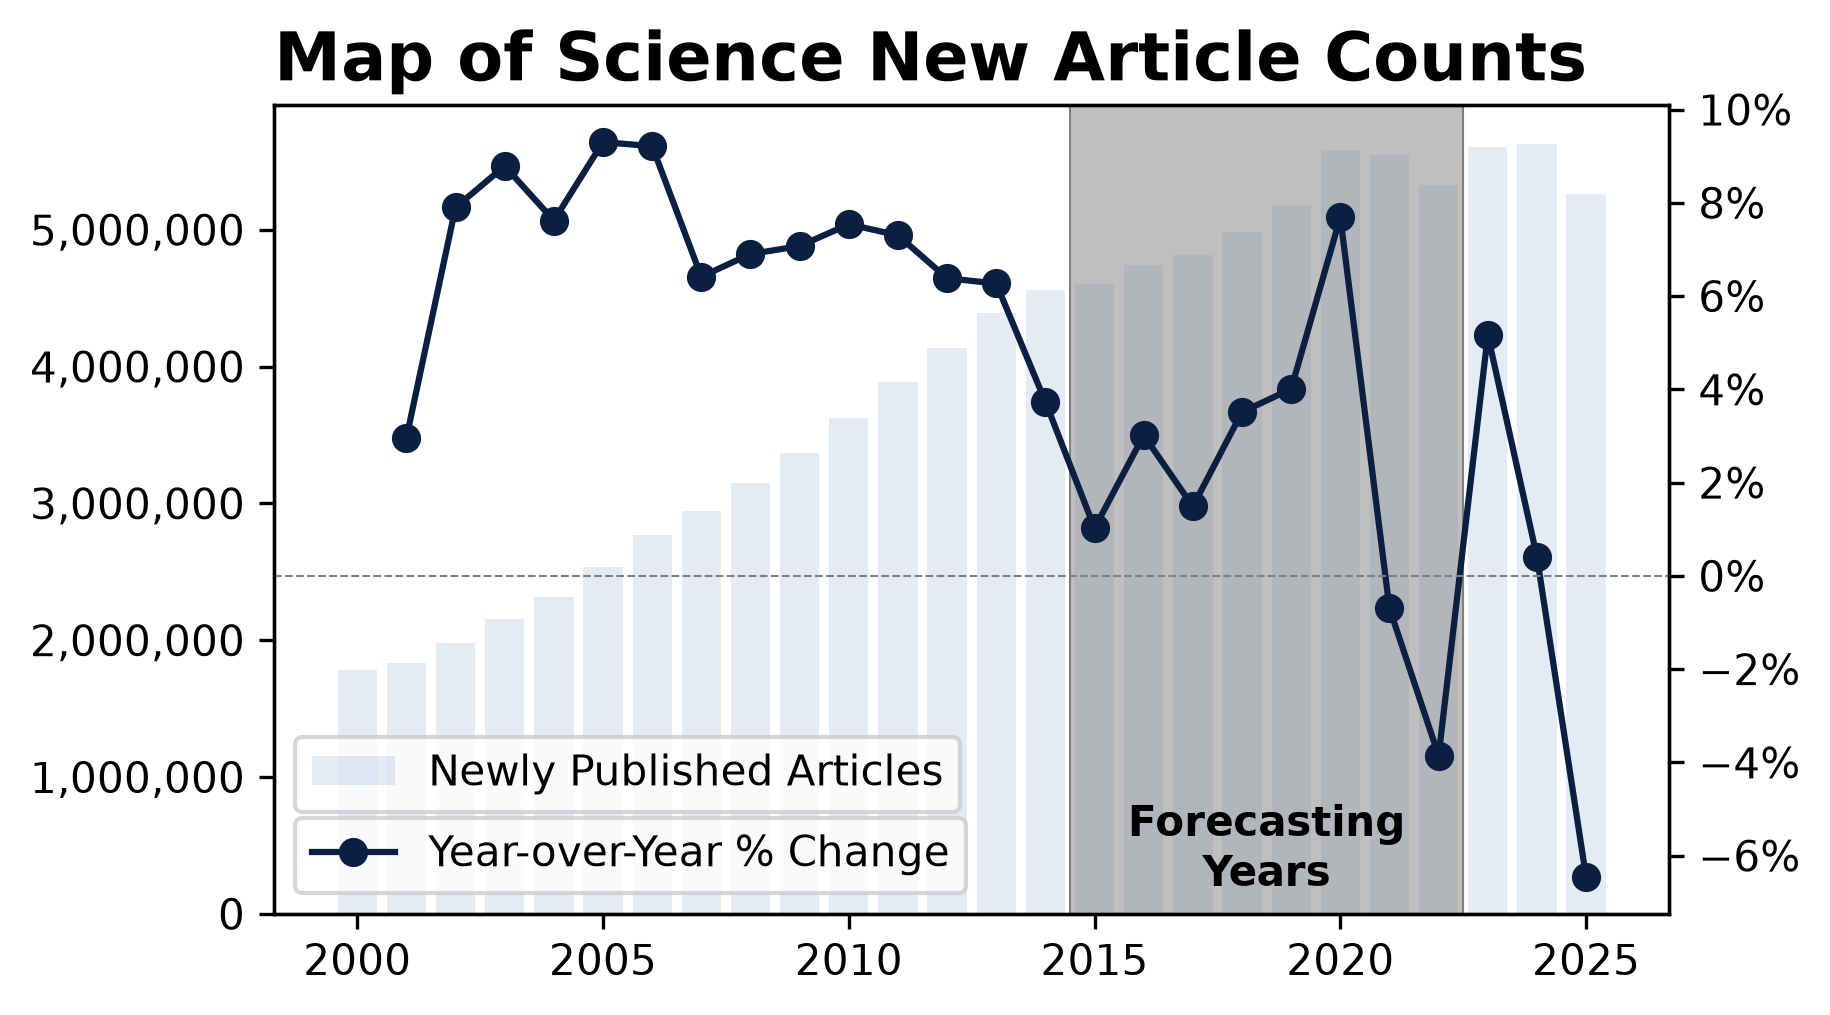

In [59]:
plt.figure(figsize=(6,3.5), dpi=300)
plt.bar(yearly_counts['year'], yearly_counts['n_articles'], 
             label = 'Newly Published Articles',
             color = cset_colors[1], alpha = 0.1)
#plt.axvspan(2014.5, 2024.5, color='grey', alpha=0.1, lw=0)
#plt.axvspan(2014.5, 2023.5, color='grey', alpha=0.1, lw=0) 
plt.axvspan(2014.5, 2022.5, color='grey', alpha=0.5, lw=0) 
#plt.axvspan(2014.5, 2021.5, color='grey', alpha=0.1, lw=0) 
#plt.axvspan(2014.5, 2020.5, color='grey', alpha=0.1, lw=0) 
plt.axvline(x=2014.5, color='grey', linestyle='-', linewidth=0.5)
#plt.axvline(x=2020.5, color='grey', linestyle='-', linewidth=0.5)
#plt.axvline(x=2021.5, color='grey', linestyle='-', linewidth=0.5)
plt.axvline(x=2022.5, color='grey', linestyle='-', linewidth=0.5)
#plt.axvline(x=2023.5, color='grey', linestyle='-', linewidth=0.5)
#plt.axvline(x=2024.5, color='grey', linestyle='-', linewidth=0.5)
plt.annotate('Forecasting\nYears', (2018.5,0.1e6), fontweight='bold',
             bbox=dict(facecolor='none', edgecolor='none', pad=5),
             verticalalignment='bottom', horizontalalignment='center')
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title('Map of Science New Article Counts', fontweight='bold', loc='left', fontsize=16)
plt.legend(bbox_to_anchor=(0, 0.1), loc='lower left')

axr = plt.gca().twinx()
counts = np.array(yearly_counts['n_articles'])
y = (counts[1:] - counts[0:-1])/counts[0:-1]
axr.plot(yearly_counts['year'][1:], 100*y, '-o',
              c=cset_colors[0], label = 'Year-over-Year % Change')

axr.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}%'))

axr.axhline(y=0, color='grey', linestyle='--', linewidth=0.5)
plt.legend(bbox_to_anchor=(0, 0), loc='lower left')

plt.savefig('../figures/merged_corpus_yearly_counts.png', transparent=True, bbox_inches='tight')
plt.savefig('../figures/merged_corpus_yearly_counts.pdf', bbox_inches='tight')

plt.show()

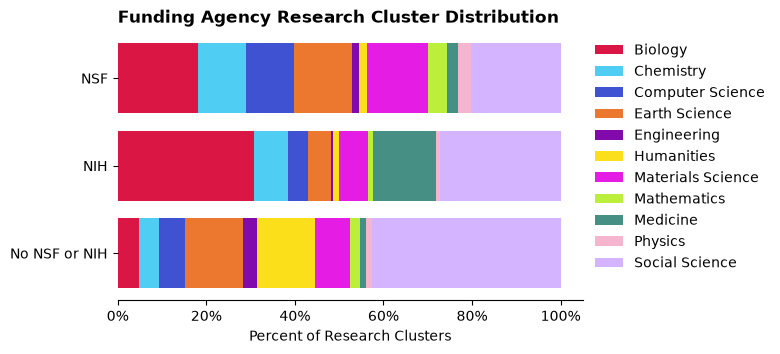

In [262]:
plt.figure(figsize=(6,3.5))

offset = np.array([0.0, 0.0, 0.0])
for k,v in mos_color_dict.items():
    labels = ['NSF','NIH','No NSF or NIH']
    vals = np.array([NSF_stats[NSF_stats['class_art'] == k]['frac_of_nsf'].values[0], 
            NIH_stats[NIH_stats['class_art'] == k]['frac_of_nih'].values[0],
            NSF_NIH_stats[NSF_NIH_stats['class_art'] == k]['frac_of_nonnsfnih'].values[0]
           ])
    plt.barh(labels, vals, left=offset, label=k.title(), color=v)
    offset += vals
    
plt.gca().invert_yaxis()
plt.xlabel('Percent of Research Clusters')
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.legend(bbox_to_anchor=(1, 1), loc="upper left", frameon=False)

plt.title('Funding Agency Research Cluster Distribution', weight='bold', loc='left')
plt.gca().spines[['top','right','left']].set_visible(False)

plt.savefig('funding_agency_research_cluster_distribution.pdf', bbox_inches='tight')
plt.savefig('funding_agency_research_cluster_distribution.png', transparent=True, bbox_inches='tight')

plt.show()

In [217]:
nsf_tmp = NSF_stats[['class_art','n_nsf']]
nih_tmp = NIH_stats[['class_art','n_nih']]
nsf_nih_tmp = NSF_NIH_stats[['class_art','n_nsf_nih','n_all']]
field_distribution_df = pd.merge(pd.merge(nsf_tmp, nih_tmp, on='class_art'), nsf_nih_tmp, on='class_art')

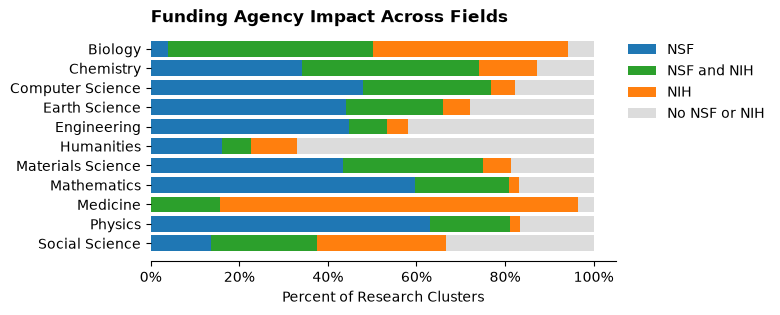

In [376]:
only_nsf = (field_distribution_df['n_nsf_nih'] - field_distribution_df['n_nih']) / field_distribution_df['n_all']
only_nih = (field_distribution_df['n_nsf_nih'] - field_distribution_df['n_nsf']) / field_distribution_df['n_all']
nsf_nih = (field_distribution_df['n_nsf'] + field_distribution_df['n_nih'] - field_distribution_df['n_nsf_nih']) / field_distribution_df['n_all']
non_nsf_nih = (field_distribution_df['n_all'] - field_distribution_df['n_nsf_nih']) / field_distribution_df['n_all']

labels = [c.title() for c in field_distribution_df['class_art'].values]

plt.figure(figsize=(6,3))

plt.barh(labels, only_nsf, 
         label='NSF', color=cset_colors[0])
plt.barh(labels, nsf_nih, left = only_nsf, 
         label='NSF and NIH', color=cset_colors[2])
plt.barh(labels, only_nih, left = only_nsf + nsf_nih, 
         label='NIH', color=cset_colors[1])
plt.barh(labels, non_nsf_nih, left = only_nsf + nsf_nih + only_nih, 
         label='No NSF or NIH', color='gainsboro')

plt.gca().invert_yaxis()
plt.xlabel('Percent of Research Clusters')
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.legend(bbox_to_anchor=(1, 1), loc="upper left", frameon=False)

plt.title('Funding Agency Impact Across Fields', weight='bold', loc='left')
plt.gca().spines[['top','right','left']].set_visible(False)

plt.savefig('../figures/funding_agency_impact_across_fields.png', transparent=True, bbox_inches='tight')
plt.savefig('../figures/funding_agency_impact_across_fields.pdf', transparent=True, bbox_inches='tight')

plt.show()

# Example Cluster with Extereme Growth

In [60]:
series_data2020 = all_cluster_data_predictions[all_cluster_data_predictions['forecast_year'] == 2020]
series_data2022 = all_cluster_data_predictions[all_cluster_data_predictions['forecast_year'] == 2022]

In [61]:
example_series = series_data2022[(series_data2022['peak_year'] == 2020) & (series_data2022['GR3'] >= 1.08) & (series_data2022['GR1'] < 1.08) & (series_data2022['GR2'] < 1.08)]
print(f"There are {len(example_series)} clusters in the example criteria.")

query_text = f"""

SELECT
    cluster_id,
    cluster_title
FROM staging_map_of_science.cluster_titles_summaries
WHERE cluster_id IN ({", ".join([str(e) for e in example_series['cluster_id'].values])})
LIMIT 10

"""
query = client.query(query_text)
exmple_series_titles = pd.DataFrame([{k:v for k,v in row.items()} for row in query])

example_series = pd.merge(example_series, exmple_series_titles, on='cluster_id', how='inner')

There are 56 clusters in the example criteria.


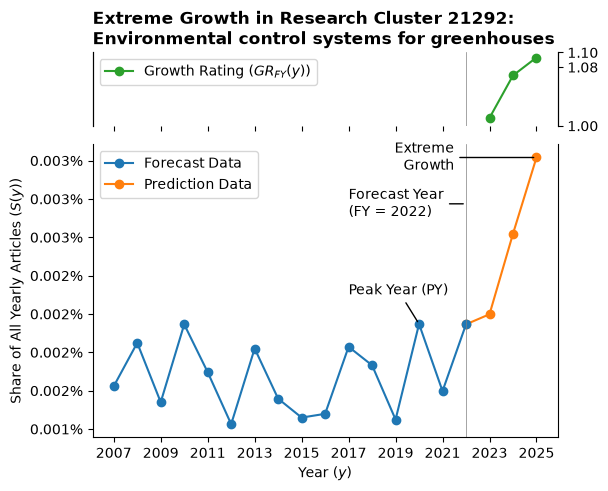

In [306]:
fig, axs = plt.subplots(figsize=(6,5), nrows=2, 
                        sharex = True, gridspec_kw={'height_ratios': [1, 4]})
plt.subplots_adjust(hspace=0.1)
idx = 5
data_plot = example_series.iloc[idx]
cluster_title = data_plot['cluster_title']
cluster_id = data_plot['cluster_id']
x1 = range(2022-15, 2022+1, 1)
y_list = [f'S{i}' for i in range(16)]
y_list_cits = [f'CS{i}' for i in range(16)]
y_list_refs = [f'RS{i}' for i in range(16)]
y_list.reverse()
y_list_cits.reverse()
y_list_cits.reverse()
y1 = 100*data_plot[y_list]
yc = 100*data_plot[y_list_cits]
yr = 100*data_plot[y_list_refs]

x2 = range(2022, 2022+4, 1)
y2 = 100*data_plot[['S0'] + [f'Share{i+1}' for i in range(3)]]


axs[1].plot(x1, y1, marker='o', c=cset_colors[0], label='Forecast Data')
axs[1].plot(x2, y2, marker='o', c=cset_colors[1], label='Prediction Data', zorder=1)
axs[1].legend()

axs[0].set_title(f"Extreme Growth in Research Cluster {cluster_id}:\n{cluster_title}", weight='bold', loc='left')
axs[1].set_ylabel(r'Share of All Yearly Articles $(S(y))$')
axs[1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.3f}%'))
axs[1].axvline(x=2022, color='grey', linestyle='-', linewidth=0.5)

#axs[1].annotate('Forecast Year\n(FY = 2022)', (2022,min(y1)), fontweight='bold',
#             bbox=dict(facecolor='white', edgecolor='grey', linewidth=0.5, pad=5),
#             verticalalignment='bottom', horizontalalignment='center')
axs[1].annotate('Peak Year (PY)', xy=(2020, max(y1)), xycoords='data',
    xytext=(2017, 1.1*max(y1)),# textcoords='offset points',
    arrowprops=dict(arrowstyle="-"))
axs[1].annotate('Extreme\nGrowth', xy=(2025, y2['Share3']), xycoords='data',
    xytext=(2021.5, y2['Share3']), ha='right', va='center',
    arrowprops=dict(arrowstyle="-"))
axs[1].annotate('Forecast Year\n(FY = 2022)', xy=(2022, 0.9*max(y2)), xycoords='data',
    xytext=(2017, 0.9*max(y2)), ha='left', va='center',
    arrowprops=dict(arrowstyle="-"))

axs[1].set_xticks(range(2005,2026,2))

x3 = range(2023,2026,1)
y3 = data_plot[[f'GR{i+1}' for i in range(3)]]

axs[0].set_yticks([])
axr = axs[0].twinx()
axr.plot(x3, y3, marker='o', c=cset_colors[2], label=r'Growth Rating $(GR_{FY}(y))$')
axr.axvline(x=2022, color='grey', linestyle='-', linewidth=0.5)
axr.set_yticks([1,1.08,1.1])
axr.legend()
axs[1].set_xlabel(r'Year $(y)$')

axs[0].spines[['bottom', 'top']].set_visible(False)
axr.spines[['top','bottom']].set_visible(False)
axs[1].spines[['top']].set_visible(False)

plt.savefig('../figures/example_cluster.png', transparent=True, bbox_inches='tight')
plt.savefig('../figures/example_cluster.pdf', bbox_inches='tight')

plt.show()

In [63]:
p1 = all_cluster_data_predictions['GR1'].quantile(0.95)
p2 = all_cluster_data_predictions['GR2'].quantile(0.95)
p3 = all_cluster_data_predictions['GR3'].quantile(0.95)
p_avg = (p1 + p2 + p3)/3

In [64]:
print(f'95th precentile for:\nGR1 = {p1}\nGR1 = {p2}\nGR3 = {p3}\nAverage = {p_avg}')

95th precentile for:
GR1 = 1.0770358477867508
GR1 = 1.0821558047604585
GR3 = 1.082903695194775
Average = 1.080698449247328


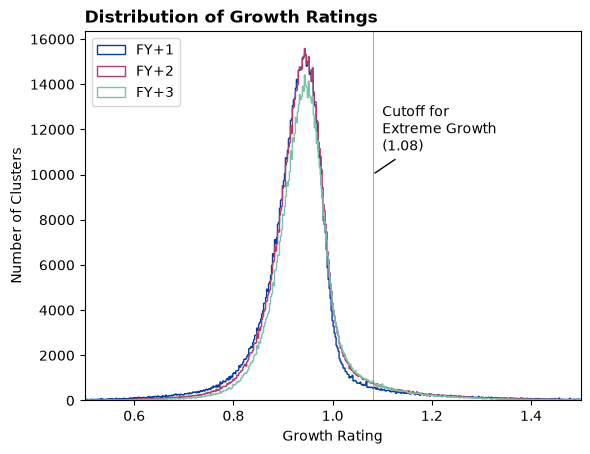

In [65]:
bins=np.linspace(0,2,1000)
plt.hist(all_cluster_data_predictions['GR1'],bins=bins, histtype='step',
         color=cset_colors[1], label='FY+1')
plt.hist(all_cluster_data_predictions['GR2'],bins=bins, histtype='step',
         color=cset_colors[2], label='FY+2')
plt.hist(all_cluster_data_predictions['GR3'].dropna(),bins=bins, histtype='step',
         color=cset_colors[3], label='FY+3')
plt.xlim([0.5,1.5])
plt.axvline(x=p_avg, color='grey', linestyle='-', linewidth=0.5)
plt.annotate(f'Cutoff for\nExtreme Growth\n({p_avg:.2f})', 
             xy=(p_avg, 10000), xycoords='data',
             xytext=(1.1, 12000), ha='left', va='center',
             arrowprops=dict(arrowstyle="-"))

plt.legend()

plt.title('Distribution of Growth Ratings', weight='bold', loc='left')
plt.xlabel('Growth Rating')
plt.ylabel('Number of Clusters')

plt.show()

# Research Activity Overlap

In [66]:
query_text = """

WITH
cluster_types AS (
  SELECT
    cluster_id,
    high_recent_activity,
    pred
  FROM IEEE_2026_paper_submission.research_activity_nopartition
  INNER JOIN IEEE_2026_paper_submission.growth_prediction USING(cluster_id)
)

SELECT
  *
FROM cluster_types
PIVOT(COUNT(DISTINCT cluster_id) FOR pred IN (0 AS noEG, 1 AS EG))

"""

query = client.query(query_text)
cluster_types = pd.DataFrame([{k:row[k] for k in row.keys()} for row in query]).set_index('high_recent_activity')

In [67]:
cluster_types

,noEG,EG
high_recent_activity,,
False,76369,6062
True,7481,1682


In [68]:
odds_ratio, p_value = fisher_exact(cluster_types.values)
print(f"Odds Ratio: {odds_ratio}")
print(f"P-value: {p_value}")

Odds Ratio: 2.8324842818567184
P-value: 5.2076932207329825e-226


In [71]:
node_labels = ["No High Recent<br>Research Activity", "High Recent<br>Research Activity", "Extreme Growth<br>Predicted", "No Extreme Growth<br>Predicted"]
node_x = [0.2, 0.2, 0.8, 0.8]
offset_x = 0.03
label_x = [0.2 - offset_x, 0.2 - offset_x, 0.8 + offset_x, 0.8 + offset_x]
node_y = [0.9, 0.1, 0.9, 0.1]
text_positions = ["middle left", "middle left", "middle right", "middle right"]

sankey_trace = go.Sankey(
                    arrangement='fixed',
                    node = dict(
                      pad = 15,
                      thickness = 20,
                      line = dict(color = "black", width = 0.5),
                      label = [""] * len(node_labels),
                      color = [cset_colors[0], cset_colors[0], cset_colors[1], cset_colors[1]],
                      x = node_x,
                      y = node_y
                    ),
                    link = dict(
                      source = [0, 0, 1, 1],
                      target = [2, 3, 2, 3],
                      value = [cluster_types.loc[False]['noEG'], cluster_types.loc[False]['EG'], cluster_types.loc[True]['noEG'], cluster_types.loc[True]['EG']]
                  )
                )

label_trace = go.Scatter(
    x = label_x,
    y = node_y,
    mode = 'text',
    text = node_labels,
    textposition=text_positions
)
    

fig = go.Figure(data=[sankey_trace, label_trace])

fig.update_layout(
    title = 'Overlap Between High Recent Activity Clusters and<br>those Predicted to Experience Extreme Growth',
    font_size=12,
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False, range=[0, 1]),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False, range=[0, 1]),
    plot_bgcolor="white"
)

fig.write_image("../figures/sankey_research_activity_extreme_growth.png")
fig.write_image("../figures/sankey_research_activity_extreme_growth.pdf")
fig.show()

In [72]:
chi2_contingency(cluster_types.values)

Chi2ContingencyResult(statistic=1288.3185140729368, pvalue=3.9064402813078624e-282, dof=1, expected_freq=array([[75461.70436928,  6969.29563072],
       [ 8388.29563072,   774.70436928]]))